In [ ]:
# https://www.kaggle.com/competitions/HyperLeaf2024
# https://openaccess.thecvf.com/content/CVPR2024W/FGVC11/papers/Laprade_HyperLeaf2024_-_A_Hyperspectral_Imaging_Dataset_for_Classification_and_Regression_CVPRW_2024_paper.pdf

🧪 HyperLeaf2024 Dataset Analysis Notebook
We will structure this notebook into sections:

🔹 Table of Contents
1. Introduction
Setup & Dependencies
Load Train/Test Data
Visualize Hyperspectral Images
Analyze Targets (Regression & Classification)
Explore Spectral Profiles
Correlation Analysis Between Targets
Conclusion
Let’s begin.

📝 1. Introduction
This notebook provides an exploratory analysis of the HyperLeaf2024 dataset , a hyperspectral imaging dataset for wheat flag leaves used in classification and regression tasks. The dataset includes:

2410 hyperspectral images of wheat leaves.
Dimensions: 48 × 352 spatial × 204 spectral bands (400–1000 nm).
Targets:
Regression: GrainWeight, Gsw, PhiPS2, Fertilizer
Classification: Cultivar – Heerup, Kvium, Rembrandt, Sheriff
The goal is to understand patterns in the hyperspectral data and prepare for model training.



In [ ]:
#@title upload kaggle.json file
%cd /content/
from google.colab import files

uploaded = files.upload()



In [1]:
#@title Download Dataset
!pip install -q kaggle
%cd /content
!rm -rf /content/kaggle.json
# !gdown https://drive.google.com/uc?id=<id>
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c hyperleaf2024
!unzip /content/hyperleaf2024.zip -d hyperleaf2024
from IPython.display import clear_output
clear_output()


In [2]:
#@title Install required libraries
# !pip install tifffile pandas numpy matplotlib seaborn scikit-learn spectral torch torchvision
!pip install spectral
!pip install rasterio
from IPython.display import clear_output
clear_output()


In [3]:
#@title import
import os
import tifffile as tiff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import spectral

In [4]:
# Set up paths:
DATA_DIR = Path("/content/hyperleaf2024")
IMAGE_DIR = DATA_DIR / "images"
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"


In [5]:


# Load train CSV
train_df = pd.read_csv("hyperleaf2024/train.csv", dtype={"ImageId": str})
train_df["ImageId"] = train_df["ImageId"].astype(int).astype(str).str.zfill(5)

# Load test CSV
test_df = pd.read_csv("hyperleaf2024/test.csv", dtype={"ImageId": str})
test_df["ImageId"] = test_df["ImageId"].astype(int).astype(str).str.zfill(5)

print("Train DataFrame Shape:", train_df.shape)
print("Test DataFrame Shape:", test_df.shape)
display(train_df.head())
display(train_df.describe())
display(train_df.info())

Train DataFrame Shape: (1590, 9)
Test DataFrame Shape: (820, 1)


,ImageId,GrainWeight,Gsw,PhiPS2,Fertilizer,Heerup,Kvium,Rembrandt,Sheriff
0,00000,4004,0.067527,0.627443,0.0,0,1,0,0
1,00001,6753,0.062773,0.664247,0.5,0,0,0,1
2,00003,8082,0.123482,0.425904,1.0,0,0,1,0
3,00007,8520,0.007312,0.691565,1.0,0,0,0,1
4,00009,8520,0.129374,0.502281,1.0,0,0,0,1


,GrainWeight,Gsw,PhiPS2,Fertilizer,Heerup,Kvium,Rembrandt,Sheriff
count,1590.000000,1590.000000,1590.000000,1590.000000,1590.000000,1590.000000,1590.000000,1590.000000
mean,6355.477987,0.058049,0.553033,0.578616,0.257862,0.220126,0.270440,0.251572
std,2109.654578,0.030702,0.105888,0.467760,0.437595,0.414462,0.444327,0.434053
min,3100.000000,-0.009612,0.136364,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4220.000000,0.038092,0.466400,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6591.000000,0.056796,0.536106,1.000000,0.000000,0.000000,0.000000,0.000000
75%,8193.000000,0.078823,0.662938,1.000000,1.000000,0.000000,1.000000,1.000000
max,9742.000000,0.157276,0.741180,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ImageId      1590 non-null   object 
 1   GrainWeight  1590 non-null   int64  
 2   Gsw          1590 non-null   float64
 3   PhiPS2       1590 non-null   float64
 4   Fertilizer   1590 non-null   float64
 5   Heerup       1590 non-null   int64  
 6   Kvium        1590 non-null   int64  
 7   Rembrandt    1590 non-null   int64  
 8   Sheriff      1590 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 111.9+ KB


None



### 🔍 Dataset Overview

This project uses the dataset provided in the [HyperLeaf 2024 competition](https://www.kaggle.com/competitions/HyperLeaf2024/overview), which focuses on predicting wheat cultivar traits using hyperspectral imaging.

---

#### 📁 Folder Structure

The dataset is organized as follows:

```
/content/hyperleaf2024
├── images/
│   ├── 00000.tiff
│   ├── 00001.tiff
│   └── ...
├── train.csv
├── test.csv
└── sample_submission.csv
```

* **`images/` folder:**
  Contains hyperspectral `.tiff` images of individual wheat leaves. Each image file name (e.g., `00000.tiff`) corresponds to an `ImageId` in the CSV files.

---

### 🧾 `train.csv` Structure

The `train.csv` file contains the ground truth labels for training. Each row corresponds to a wheat leaf sample, with the following columns:

| Column          | Description                                                                                                                          |
| --------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| **ImageId**     | The unique ID of the leaf image. It matches the filename in the `images/` folder (e.g., `02410.tiff` corresponds to `ImageId=2410`). |
| **GrainWeight** | Estimated weight of grains from the plant (continuous value).                                                                        |
| **Gsw**         | Grain-specific weight or density (continuous value).                                                                                 |
| **PhiPS2**      | A photosynthetic efficiency metric (ΦPSII), indicating light-use efficiency in the plant's photosystem II (continuous value).        |
| **Fertilizer**  | Amount of fertilizer applied to the plant during growth (continuous value).                                                          |
| **Heerup**      | One-hot encoded label: 1 if the sample belongs to the "Heerup" cultivar, else 0.                                                     |
| **Kvium**       | One-hot encoded label: 1 if the sample belongs to the "Kvium" cultivar, else 0.                                                      |
| **Rembrandt**   | One-hot encoded label: 1 if the sample belongs to the "Rembrandt" cultivar, else 0.                                                  |
| **Sheriff**     | One-hot encoded label: 1 if the sample belongs to the "Sheriff" cultivar, else 0.                                                    |

---

### 🎯 Prediction Targets

The task is to build a model that can predict **both regression and classification outputs** from hyperspectral images of leaves.

#### ✅ **Regression Targets:**

These are continuous variables you need to predict for each image:

* `GrainWeight`
* `Gsw`
* `PhiPS2`
* `Fertilizer`

#### ✅ **Classification Target:**

The cultivar of the leaf, encoded as four binary columns (`Heerup`, `Kvium`, `Rembrandt`, `Sheriff`). Only one of these columns will be `1` for each row — making it a **multi-class classification** problem, represented in **one-hot format**.

---

### 📌 Summary of the Task

* Input: Hyperspectral `.tiff` image (with hundreds of spectral bands per pixel).
* Output:

  * 4 continuous values (regression).
  * 1 class label from 4 possible cultivars (classification, represented as one-hot).

This makes the task a **multi-output supervised learning problem**, combining **regression** and **multi-class classification**.






## RGB Visualization from Hyperspectral Data (HyperLeaf2024)

I'm using the **HyperLeaf2024** dataset for my project. This dataset was captured using the **SpecimIQ hyperspectral camera**, which records 204 spectral bands from **400 nm to 1000 nm**.

### Step 1: Calculate Band Width

To find out the wavelength each band represents, we calculate the band spacing like this:

```

Band Width = (1000 nm - 400 nm) / 204 = 2.94 nm per band

```

So, each band represents about **2.94 nanometers**.

---

### Step 2: Map RGB Wavelengths to Band Numbers

We want to simulate an RGB image by selecting hyperspectral bands that are close to the red, green, and blue visible light wavelengths:

| Color | Wavelength | Calculation | Approx Band Number |
|-------|------------|-------------|---------------------|
| Blue  | 470 nm     | (470 - 400) / 2.94 ≈ 24  | 24  |
| Green | 550 nm     | (550 - 400) / 2.94 ≈ 51  | 51  |
| Red   | 660 nm     | (660 - 400) / 2.94 ≈ 88  | 88  |

---

### Step 3: Use These Bands to Create RGB

To visualize an RGB image:
- Use **Band 88** for Red
- Use **Band 51** for Green
- Use **Band 24** for Blue

This helps turn the grayscale hyperspectral data into a rough RGB image for better visual analysis.


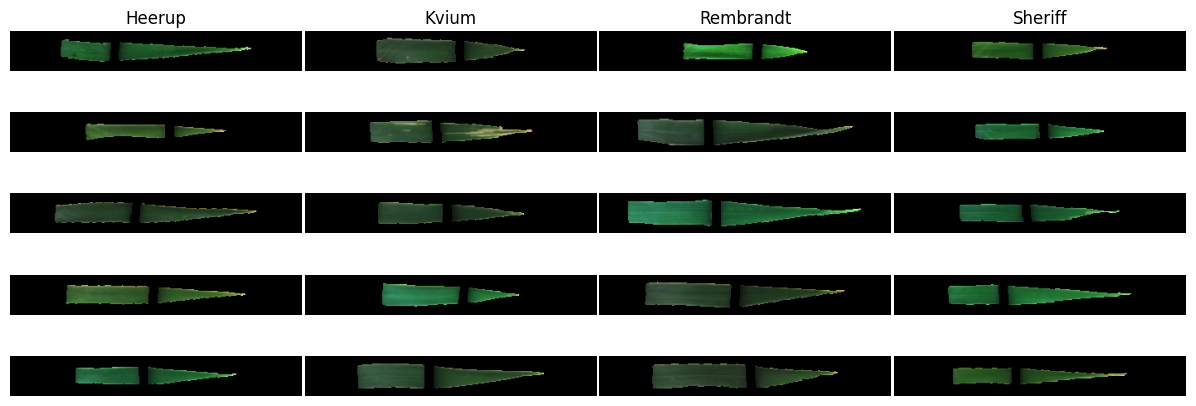

In [6]:
#@title 5 Samples from Each Wheat Cultivar (RGB from Hyperspectral)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile as tiff

# For Jupyter Notebook or Colab
%matplotlib inline

# Function to extract RGB from hyperspectral .tiff image
def tiff_to_rgb(tiff_path):
    cube = tiff.imread(tiff_path)
    blue_band = 24   # ~470 nm
    green_band = 51  # ~550 nm
    red_band = 88    # ~660 nm

    rgb = np.stack([
        cube[red_band],
        cube[green_band],
        cube[blue_band],
    ], axis=-1)

    rgb = rgb.astype(np.float32)
    rgb -= rgb.min()
    rgb /= rgb.max()

    return rgb

# Paths
data_dir = '/content/hyperleaf2024'
img_dir = os.path.join(data_dir, 'images')
train_df = pd.read_csv(os.path.join(data_dir, 'train.csv'))

# Cultivars to show
cultivars = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']
samples_per_class = 5

# Sample 5 images per cultivar
sampled_images = {
    cultivar: train_df[train_df[cultivar] == 1].sample(samples_per_class, random_state=42)['ImageId'].values
    for cultivar in cultivars
}

# Plot
fig, axes = plt.subplots(nrows=samples_per_class, ncols=len(cultivars), figsize=(12, 7),
                         gridspec_kw={'wspace': 0.01, 'hspace': 0.01})

for col, cultivar in enumerate(cultivars):
    for row in range(samples_per_class):
        img_id = str(sampled_images[cultivar][row]).zfill(5)
        img_path = os.path.join(img_dir, f"{img_id}.tiff")
        ax = axes[row, col]
        ax.axis('off')

        if os.path.exists(img_path):
            rgb_img = tiff_to_rgb(img_path)
            ax.imshow(rgb_img)

# Add column headers (cultivar names)
for col, cultivar in enumerate(cultivars):
    axes[0, col].set_title(cultivar, fontsize=12, pad=5)

# Set overall title, reduce vertical space
# fig.suptitle("5 Samples from Each Wheat Cultivar (RGB from Hyperspectral)", fontsize=16, y=0.93)
plt.subplots_adjust(top=0.60, bottom=0.02, left=0.01, right=0.99)
plt.show()


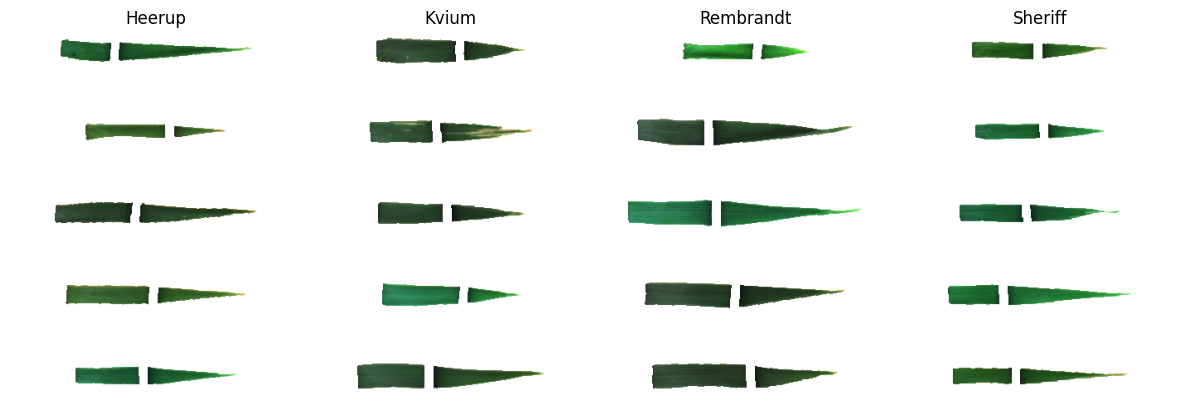

In [7]:
#@title 5 Samples from Each Wheat Cultivar (RGB from Hyperspectral with Background Removed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile as tiff

# For Jupyter Notebook or Colab
%matplotlib inline

# Function to extract RGB and remove dark background
def tiff_to_rgb_background_remove(tiff_path, background_threshold=0.05):
    cube = tiff.imread(tiff_path)

    # Approximate visible light bands
    blue_band = 24   # ~470 nm
    green_band = 51  # ~550 nm
    red_band = 88    # ~660 nm

    # Stack into RGB
    rgb = np.stack([cube[red_band], cube[green_band], cube[blue_band]], axis=-1)

    # Normalize
    rgb = rgb.astype(np.float32)
    rgb -= rgb.min()
    rgb /= rgb.max()

    # Create background mask
    background_mask = np.all(rgb <= background_threshold, axis=-1)

    # Replace dark background with white
    rgb[background_mask] = [1.0, 1.0, 1.0]

    return rgb

# Paths
data_dir = '/content/hyperleaf2024'
img_dir = os.path.join(data_dir, 'images')
train_df = pd.read_csv(os.path.join(data_dir, 'train.csv'))

# Cultivars to show
cultivars = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']
samples_per_class = 5

# Sample 5 images per cultivar
sampled_images = {
    cultivar: train_df[train_df[cultivar] == 1].sample(samples_per_class, random_state=42)['ImageId'].values
    for cultivar in cultivars
}

# Plot
fig, axes = plt.subplots(nrows=samples_per_class, ncols=len(cultivars), figsize=(12, 7),
                         gridspec_kw={'wspace': 0.01, 'hspace': 0.01})

for col, cultivar in enumerate(cultivars):
    for row in range(samples_per_class):
        img_id = str(sampled_images[cultivar][row]).zfill(5)
        img_path = os.path.join(img_dir, f"{img_id}.tiff")
        ax = axes[row, col]
        ax.axis('off')

        if os.path.exists(img_path):
            rgb_img = tiff_to_rgb_background_remove(img_path)
            ax.imshow(rgb_img)
        else:
            ax.text(0.5, 0.5, "Missing", ha='center', va='center', color='red')

# Add column headers (cultivar names)
for col, cultivar in enumerate(cultivars):
    axes[0, col].set_title(cultivar, fontsize=12, pad=5)

# plt.suptitle("5 Samples from Each Wheat Cultivar (RGB with Background Removed)", fontsize=16, y=0.92)
plt.subplots_adjust(top=0.60, bottom=0.02, left=0.01, right=0.99)
plt.show()


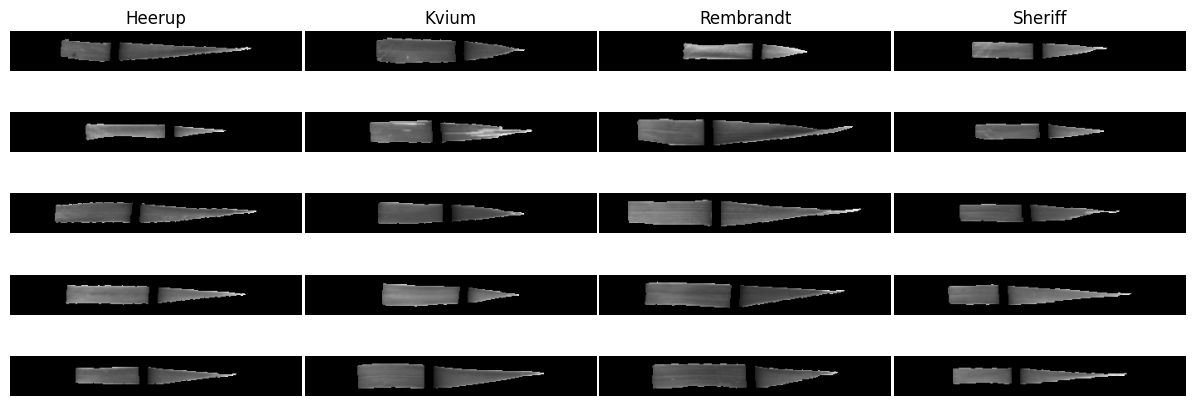

In [8]:
#@title 5 Samples from Each Wheat Cultivar (Original Hyperspectral Band 50)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile as tiff

%matplotlib inline

# Function to read one band (grayscale view)
def load_single_band(tiff_path, band=50):  # Mid-range band
    cube = tiff.imread(tiff_path)
    image = cube[band]
    image = image.astype(np.float32)
    image -= image.min()
    image /= image.max()
    return image

# Paths
data_dir = '/content/hyperleaf2024'
img_dir = os.path.join(data_dir, 'images')
train_df = pd.read_csv(os.path.join(data_dir, 'train.csv'))

# Cultivars
cultivars = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']
samples_per_class = 5

# Sample 5 images per cultivar
sampled_images = {
    cultivar: train_df[train_df[cultivar] == 1].sample(samples_per_class, random_state=42)['ImageId'].values
    for cultivar in cultivars
}

# Plot
fig, axes = plt.subplots(nrows=samples_per_class, ncols=len(cultivars), figsize=(12, 7),
                         gridspec_kw={'wspace': 0.01, 'hspace': 0.01})

for col, cultivar in enumerate(cultivars):
    for row in range(samples_per_class):
        img_id = str(sampled_images[cultivar][row]).zfill(5)
        img_path = os.path.join(img_dir, f"{img_id}.tiff")
        ax = axes[row, col]
        ax.axis('off')

        if os.path.exists(img_path):
            grayscale_img = load_single_band(img_path, band=50)
            ax.imshow(grayscale_img, cmap='gray')

# Add cultivar names
for col, cultivar in enumerate(cultivars):
    axes[0, col].set_title(cultivar, fontsize=12, pad=5)

# Title & spacing
# fig.suptitle("5 Samples from Each Wheat Cultivar (Original Hyperspectral Band 50)", fontsize=16, y=0.93)
plt.subplots_adjust(top=0.60, bottom=0.02, left=0.01, right=0.99)
plt.show()


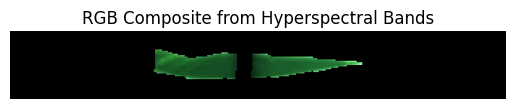

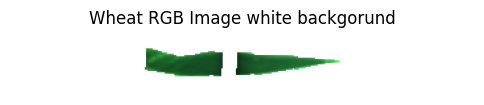

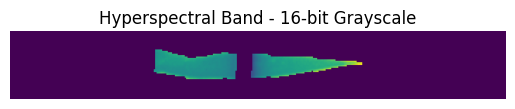

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


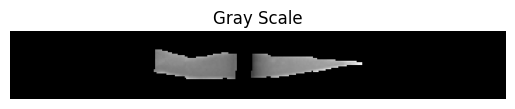

Cube shape: (204, 48, 352)


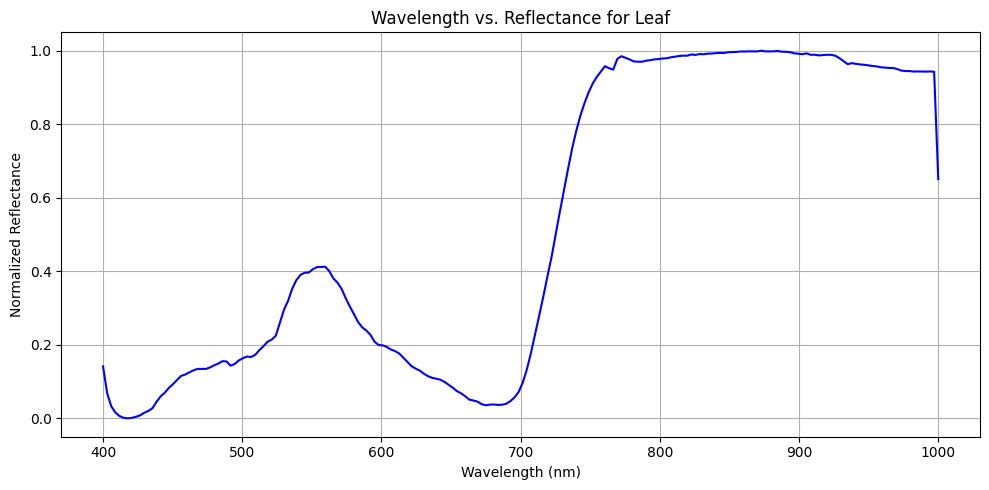

In [9]:
#@title plot single hyperspectral image and wavelength vs reflectance

import numpy as np
import tifffile as tiff

def extract_wavelength_reflectance(tiff_path, start_wavelength=400, end_wavelength=1000):
    cube = tiff.imread(tiff_path)
    print(f"Cube shape: {cube.shape}")

    num_bands = cube.shape[0]
    wavelengths = np.linspace(start_wavelength, end_wavelength, num_bands)

    # Mask where pixels are not zero in any spectral band (leaf pixels)
    foreground_mask = np.any(cube > 0, axis=0)  # shape: (height, width)

    # Get indices of leaf pixels
    ys, xs = np.where(foreground_mask)

    # Extract reflectance for all leaf pixels
    leaf_spectra = cube[:, ys, xs]

    # Average reflectance across all leaf pixels
    avg_spectrum = np.mean(leaf_spectra, axis=1)

    # Normalize average spectrum
    avg_spectrum = (avg_spectrum - avg_spectrum.min()) / (avg_spectrum.max() - avg_spectrum.min() + 1e-8)

    return wavelengths, avg_spectrum


img_path = "/content/hyperleaf2024/images/00050.tiff"  # @param {type: "string"}

rgb=tiff_to_rgb(img_path)
plt.imshow(rgb)
plt.axis('off')  # Optional: hides the axis
plt.title('RGB Composite from Hyperspectral Bands')
plt.show()

rgb_img = tiff_to_rgb_background_remove(img_path)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.axis('off')
plt.title("Wheat RGB Image white backgorund")
plt.show()



from PIL import Image
import matplotlib.pyplot as plt


# Load and show image
image = Image.open(img_path)  # Replace with your filename
# print("Image mode:", image.mode)
plt.imshow(image)
plt.title("Hyperspectral Band - 16-bit Grayscale")
plt.axis('off')
plt.show()

import rasterio
import matplotlib.pyplot as plt


# Load and plot the bands
with rasterio.open(img_path) as src:
    band1 = src.read(1)  # First band
    plt.imshow(band1, cmap='gray')
    plt.title("Gray Scale")
    plt.axis('off')
    plt.show()




wavelengths, avg_spectrum = extract_wavelength_reflectance(img_path)

# Plot Wavelength vs. Reflectance
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, avg_spectrum, color='blue')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Reflectance")
plt.title("Wavelength vs. Reflectance for Leaf")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
#@title Generate Spectral dataset
!wget https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/wheat_spectral_dataset.csv
import os
import numpy as np
import pandas as pd
import tifffile as tiff
from tqdm import tqdm
from IPython.display import clear_output
# Define paths
img_dir = "/content/hyperleaf2024/images"


# Define the cultivar columns
cultivar_cols = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']

# Create a copy of the DataFrame to preserve the original
temp_df = train_df.copy()

# Assign the cultivar name (column where value is 1) to new 'Class' column
temp_df['Class'] = temp_df[cultivar_cols].idxmax(axis=1)


# Assume temp_df already contains 'ImageId' and 'Class'
spectral_df = temp_df[['ImageId', 'Class']].copy()

# Estimate wavelength range
num_bands = 204  # Assuming 204 bands
wavelengths = np.linspace(400, 1000, num_bands)

# Create columns for each wavelength
for wl in wavelengths:
    spectral_df[f"{wl:.2f}"] = np.nan  # Use 2 decimal places as column names
clear_output()
# Reorder columns: metadata first, then spectral data
columns = ['ImageId', 'Class'] + [f"{wl:.2f}" for wl in wavelengths]
spectral_df = spectral_df[columns]
make_spectral_data = True  # @param {type: "boolean"}
if make_spectral_data:
  # Extract spectral data
  for idx, row in tqdm(spectral_df.iterrows(), total=len(spectral_df)):
      img_id = row['ImageId']
      img_id=str(img_id).zfill(5)
      img_path = os.path.join(img_dir, f"{img_id}.tiff")

      if not os.path.exists(img_path):
          print(f"Missing: {img_path}")
          continue

      try:
          wl_array, reflectance = extract_wavelength_reflectance(img_path)

          # Ensure reflectance has correct number of bands
          if len(reflectance) != num_bands:
              print(f"Unexpected number of bands in {img_id}: {len(reflectance)}")
              continue

          # Update DataFrame row
          for i, wl in enumerate(wl_array):
              col_name = f"{wl:.2f}"
              if col_name in spectral_df.columns:
                  spectral_df.at[idx, col_name] = reflectance[i]
              else:
                  print(f"Warning: Column {col_name} not found in DataFrame for {img_id}")

      except Exception as e:
          print(f"Error processing {img_id}: {e}")




  # Merge the two DataFrames on 'ImageId'
  merged_df = pd.merge(spectral_df, temp_df, on='ImageId', how='inner')

  # Drop one 'Class' column and rename the other
  merged_df = merged_df.drop(columns=['Class_x']).rename(columns={'Class_y': 'Class'})

  # Define the desired column order
  front_cols = [
      'ImageId', 'Class',
      'GrainWeight', 'Gsw', 'PhiPS2', 'Fertilizer',
      'Heerup', 'Kvium', 'Rembrandt', 'Sheriff'
  ]

  # Get all other columns (the spectral ones)
  remaining_cols = [col for col in merged_df.columns if col not in front_cols]

  # Reorder the columns
  reordered_df = merged_df[front_cols + remaining_cols]

  # Display the result
  # display(reordered_df.head())
  reordered_df.to_csv('regression_dataset.csv', index=False)

  clear_output()
  # Save to CSV
  spectral_df.to_csv("wheat_spectral_dataset_colab.csv", index=False)
  print("Saved as wheat_spectral_dataset_colab.csv")

Saved as wheat_spectral_dataset_colab.csv


🔍 Columns: <br>
ImageId: Identifier for each image (links to .tiff file)<br>
Regression targets : GrainWeight, Gsw, PhiPS2, Fertilizer<br>
Classification target (one-hot encoded) : Heerup, Kvium, Rembrandt, <br>Sheriff

In [12]:
# hyperleaf2024
# |-- images
# |   |-- 000000.tiff
# |   |-- 000001.tiff
# |   |-- ...........
# |   |-- ...........
# |   |-- 002410.tiff
# |-- test.csv
# |-- wheat_spectral_dataset.csv
# |-- train.csv


# /content/wheat_spectral_dataset.csv wheat class classification from spectral data

use https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv
My columns:

ImageId,Class,400.00,402.96,...... 1000.00

Our target is Class where we have wheat variety name its string
ImageId refers to the image id used for find image path we dont need this column
And rest of the wavelength coumsn

Sample row

0,Kvium,0.1109686722222576,0.050335272408280236, so on …..


Our task is use multiple model.
We pase wavelength refecletace and predict this belong to which type wheat leaf there are 4 calss: Heerup, Kvium, Rembrandt, Sheriff


<ipython-input-138-403210b7f89d>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ndvi_means, x="Class", y="NDVI", palette="viridis")


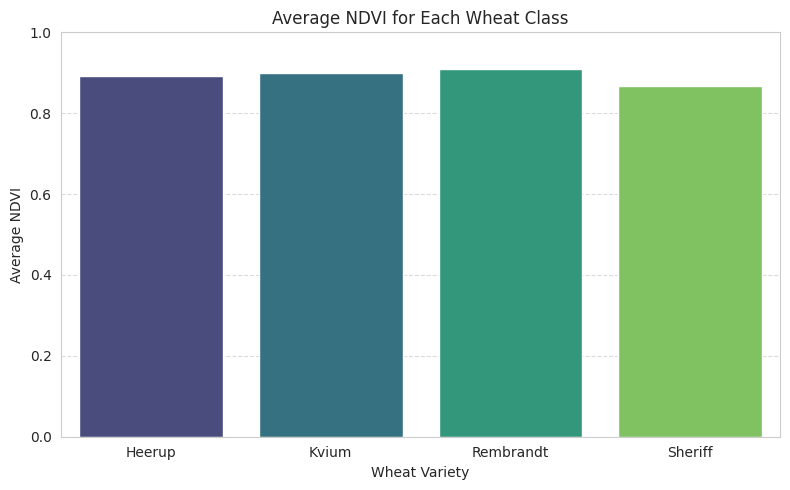

In [138]:
#@title just plot dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/wheat_spectral_dataset.csv"
df = pd.read_csv(url)

# --- Utility functions ---
def get_closest_wavelength(df, target_wavelength):
    wavelength_cols = [col for col in df.columns if col.replace('.', '', 1).isdigit()]
    numeric_cols = [float(col) for col in wavelength_cols]
    closest = min(numeric_cols, key=lambda x: abs(x - target_wavelength))
    return f"{closest:.2f}"

# Get closest Red and NIR columns
red_col = get_closest_wavelength(df, 660)
nir_col = get_closest_wavelength(df, 800)

# Calculate NDVI
df["NDVI"] = (df[nir_col] - df[red_col]) / (df[nir_col] + df[red_col] + 1e-6)  # epsilon to avoid division by 0

# Group by Class and get average NDVI
ndvi_means = df.groupby("Class")["NDVI"].mean().reset_index()

# --- Plot ---
plt.figure(figsize=(8,5))
sns.barplot(data=ndvi_means, x="Class", y="NDVI", palette="viridis")
plt.title("Average NDVI for Each Wheat Class")
plt.ylabel("Average NDVI")
plt.xlabel("Wheat Variety")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


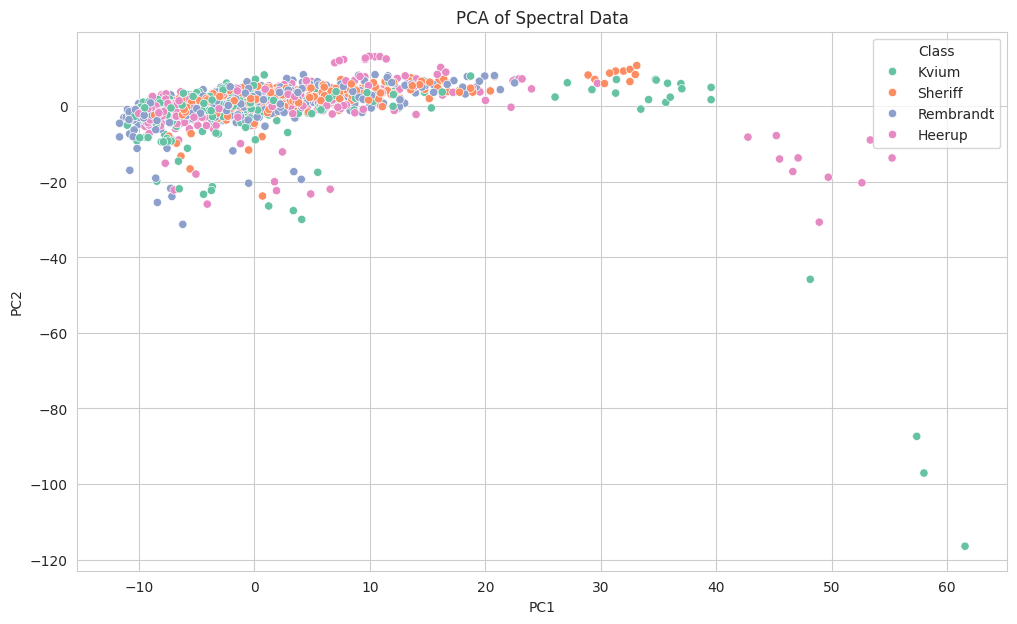

In [141]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale data
X_scaled = StandardScaler().fit_transform(df[wavelength_cols])

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Class"] = df["Class"]

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class", palette="Set2")
plt.title("PCA of Spectral Data")
plt.show()


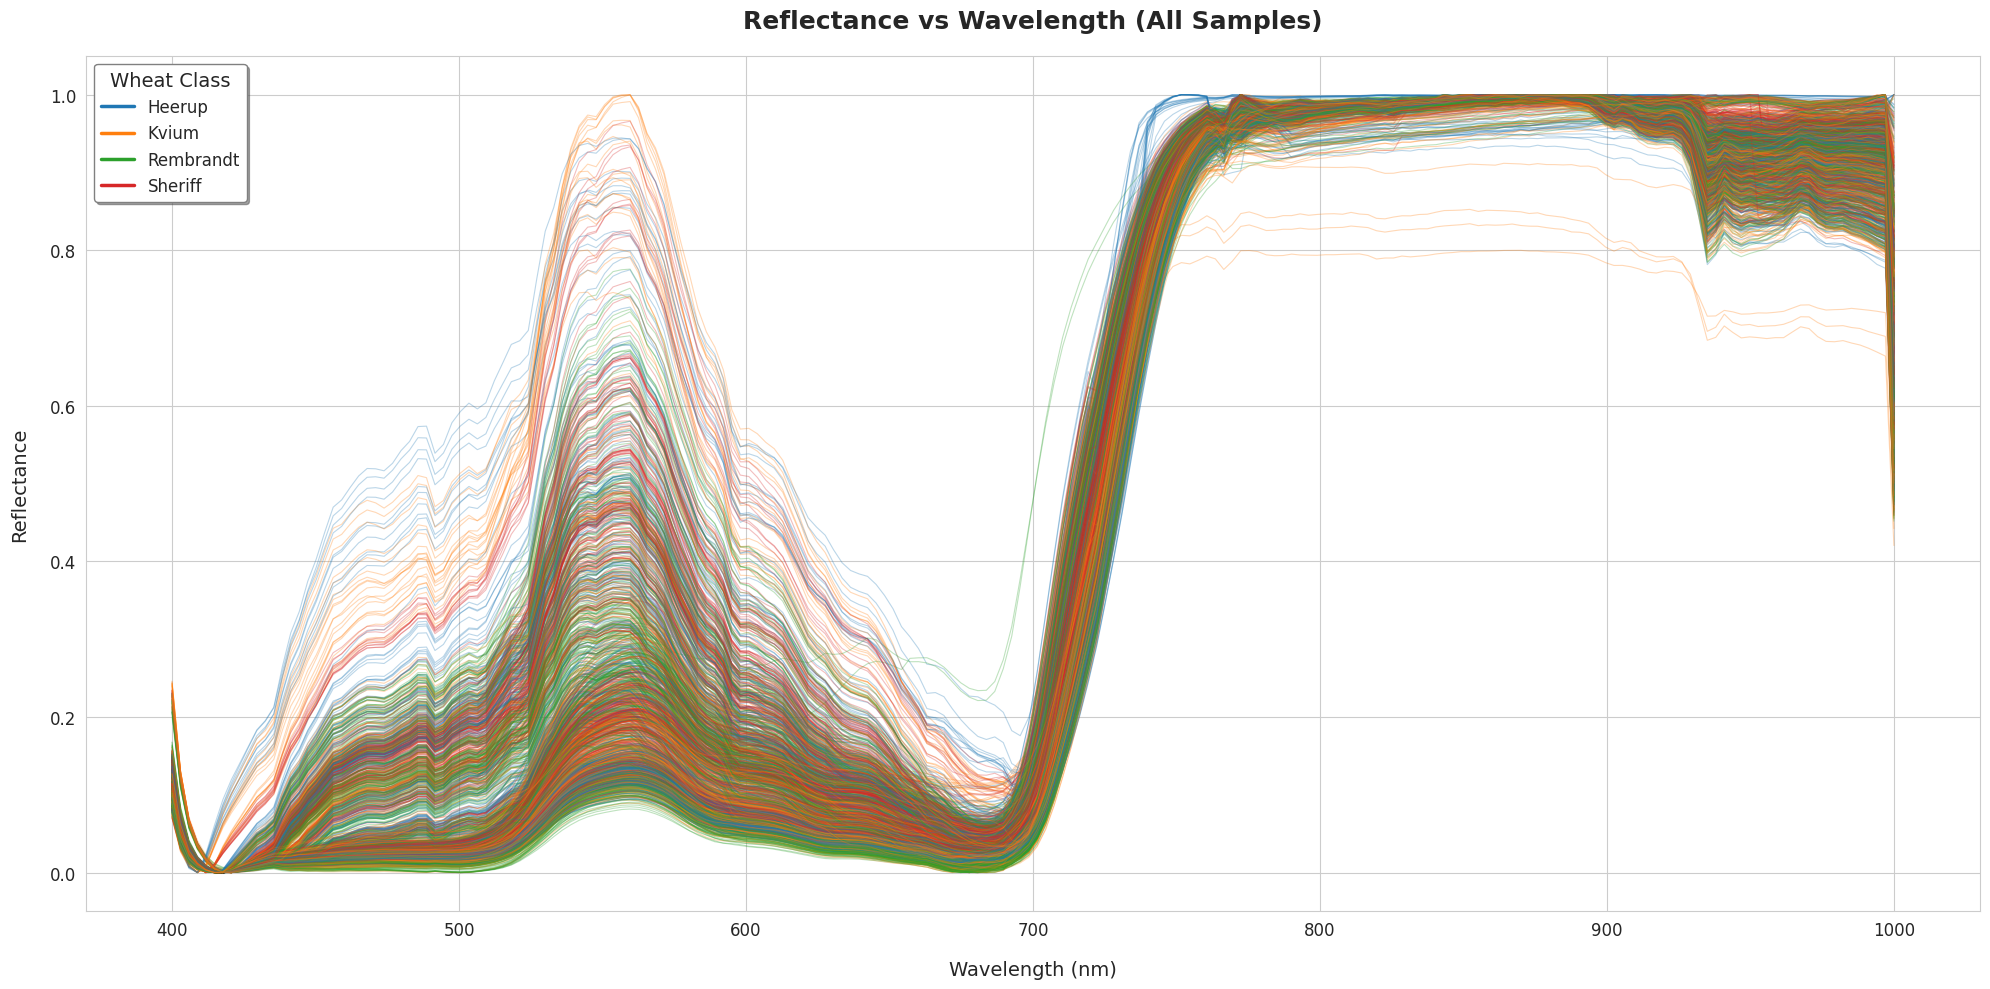

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # For improved styling and color palettes
from matplotlib.lines import Line2D  # For creating custom legend entries

# Load data
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv"
df = pd.read_csv(url)

# Filter only numeric wavelength columns
# This ensures that column names like '400.0', '400.52' etc. are selected
wavelength_cols = [col for col in df.columns if col.replace('.', '', 1).isdigit()]
# Convert wavelength column names to float for plotting
wavelengths = [float(w) for w in wavelength_cols]

# --- Aesthetic Enhancements ---

# 1. Apply a Seaborn style for better default aesthetics (e.g., grid, background)
sns.set_style("whitegrid")

# 2. Define a color palette for different wheat classes
unique_classes = sorted(df['Class'].unique())  # Sort for consistent color assignment
# 'tab10' is a good qualitative palette providing distinct and accessible colors.
# Adjust n_colors if you have a different number of classes.
palette = sns.color_palette("tab10", n_colors=len(unique_classes))
class_to_color = dict(zip(unique_classes, palette))

# 3. Plotting
# Increased figure size for better clarity and to prevent overcrowding
plt.figure(figsize=(20, 10))

# Iterate through each sample (row) in the DataFrame
for _, row in df.iterrows():
    # Extract reflectance values for the current sample
    reflectance = row[wavelength_cols].values.astype(float)
    class_label = row['Class']  # Get the class label for this sample

    # Plot the spectrum for this sample
    plt.plot(wavelengths, reflectance,
             alpha=0.3,  # Adjust alpha for transparency; good for many overlapping lines
             color=class_to_color[class_label],  # Use the specific color assigned to this class
             linewidth=0.8)  # Adjust linewidth; thinner lines can reduce clutter

# 4. Create a custom legend
# This approach ensures one clear legend entry per class, rather than for every single plotted line.
legend_elements = [Line2D([0], [0],
                          color=class_to_color[cls],
                          lw=2.5,  # Line width for legend entries (make them stand out)
                          label=cls)
                   for cls in unique_classes]

plt.legend(handles=legend_elements,
           title="Wheat Class",
           fontsize=12,             # Font size for legend item labels
           title_fontsize=14,       # Font size for legend title
           loc='upper left',        # Position the legend
           frameon=True,            # Draw a frame around the legend
           facecolor='white',       # Background color for the legend box
           edgecolor='gray',        # Border color for the legend box
           shadow=True)             # Add a subtle shadow for a polished look

# 5. Titles and Labels with improved font sizes and padding
plt.title("Reflectance vs Wavelength (All Samples)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Wavelength (nm)", fontsize=14, labelpad=15)
plt.ylabel("Reflectance", fontsize=14, labelpad=15)

# 6. Tick styling for better readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 7. Grid styling is largely handled by sns.set_style("whitegrid")
# For further customization, you could use:
# plt.grid(True, linestyle='--', alpha=0.6)

# 8. Final layout adjustment to prevent labels/titles from overlapping
plt.tight_layout()

plt.show()

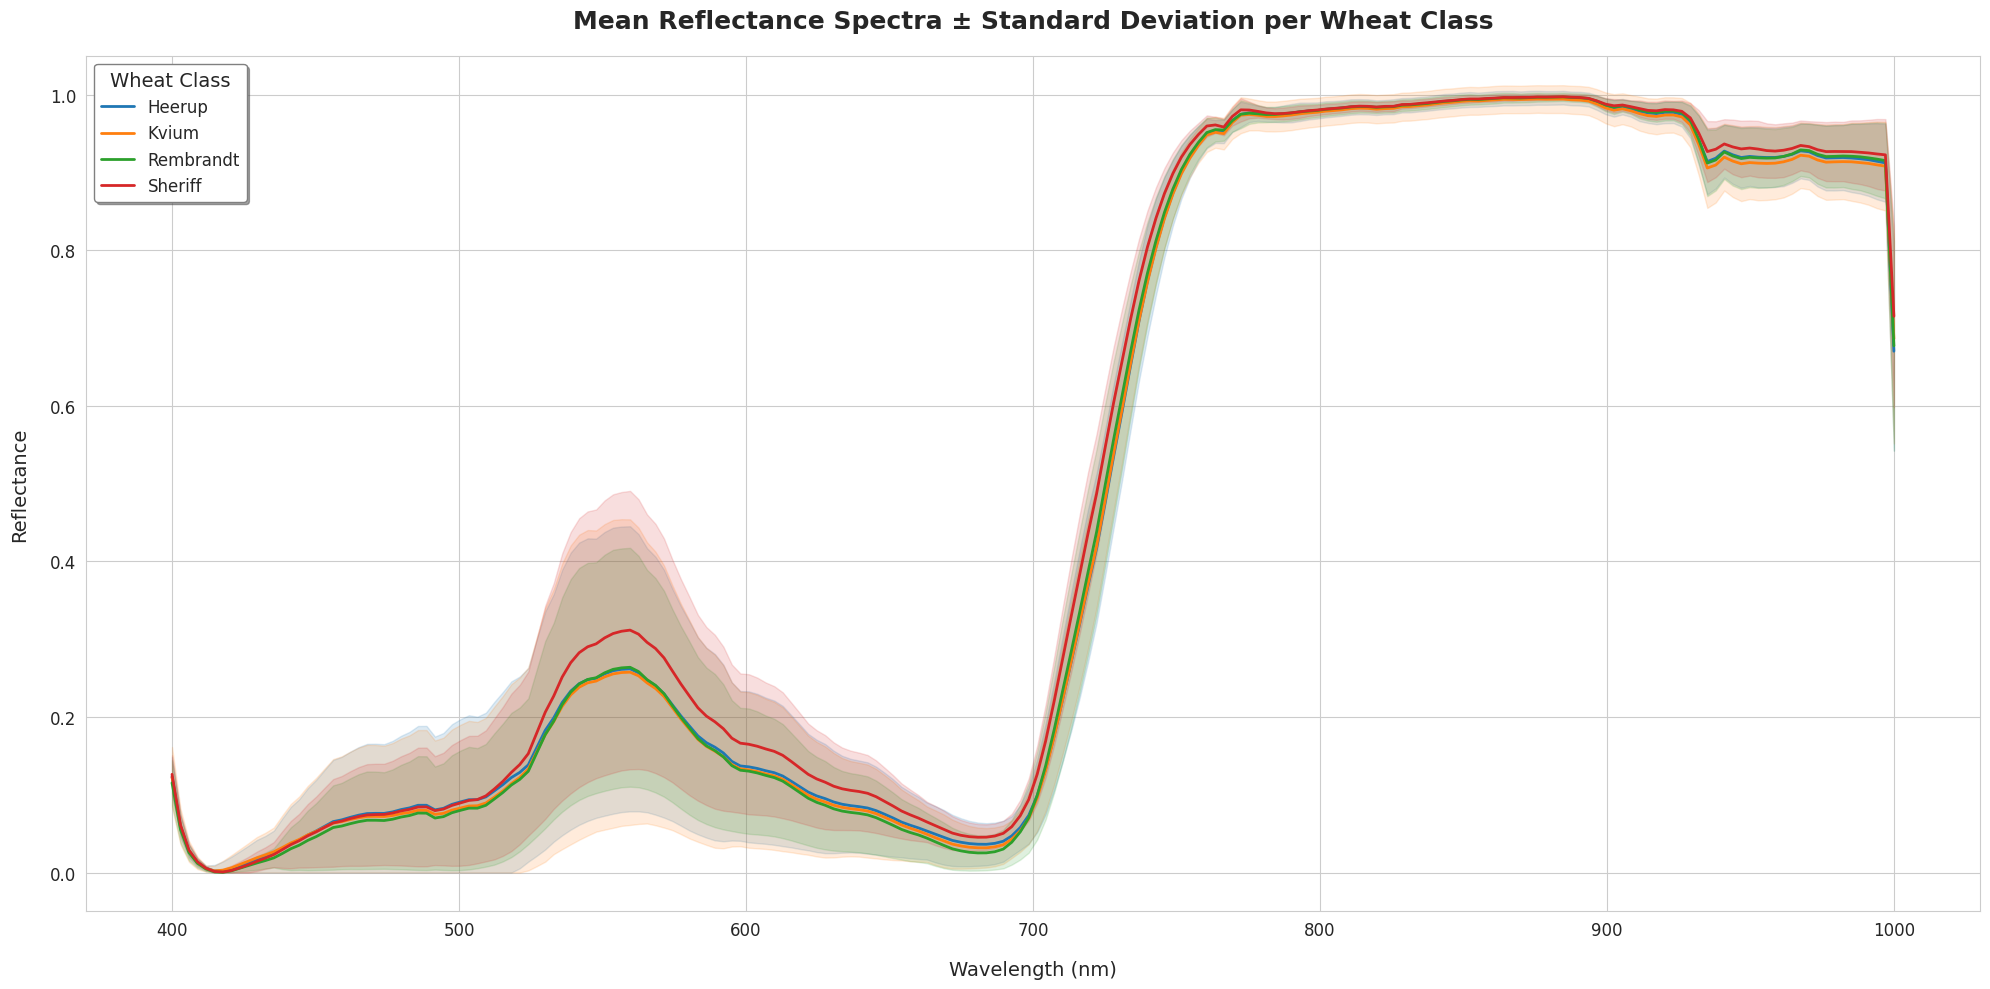

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # We'll need numpy for mean and std
from matplotlib.lines import Line2D

# Load data
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv"
df = pd.read_csv(url)

# Filter only numeric wavelength columns
wavelength_cols = [col for col in df.columns if col.replace('.', '', 1).isdigit()]
wavelengths = [float(w) for w in wavelength_cols]

# --- Aesthetic Enhancements ---

# 1. Apply a Seaborn style
sns.set_style("whitegrid")

# 2. Define a color palette
unique_classes = sorted(df['Class'].unique())
palette = sns.color_palette("tab10", n_colors=len(unique_classes))
class_to_color = dict(zip(unique_classes, palette))

# 3. Plotting
plt.figure(figsize=(20, 10))

# --- Plotting Mean and Standard Deviation ---

# Group by class to calculate statistics for each
for class_label, group in df.groupby('Class'):
    # Select only the wavelength columns and convert to float
    spectra = group[wavelength_cols].values.astype(float)

    # Calculate mean and standard deviation across all samples for this class
    mean_spectrum = np.mean(spectra, axis=0)
    std_spectrum = np.std(spectra, axis=0)

    # Define the upper and lower bounds for the shaded area (mean ± 1 std dev)
    lower_bound = mean_spectrum - std_spectrum
    upper_bound = mean_spectrum + std_spectrum

    # Ensure lower bound doesn't go below 0 (reflectance cannot be negative)
    lower_bound = np.maximum(0, lower_bound)

    # Get the color for this class
    color = class_to_color[class_label]

    # Plot the mean spectrum line (make it a bit thicker and solid)
    plt.plot(wavelengths, mean_spectrum,
             color=color,
             linewidth=2,
             label=class_label, # Label for the legend
             zorder=5) # Ensure mean lines are on top

    # Plot the shaded region (standard deviation) with transparency
    plt.fill_between(wavelengths, lower_bound, upper_bound,
                     color=color,
                     alpha=0.15, # Low alpha creates the "blurry" overlap effect
                     zorder=1) # Ensure fill is behind lines

# --- Legend and Labels ---

# Create a custom legend using the mean lines we plotted
# (We use the labels directly in the plot call, but a custom one gives more control)
# Or, simply call plt.legend() if the direct labels are sufficient.
plt.legend(title="Wheat Class",
           fontsize=12,
           title_fontsize=14,
           loc='upper left',
           frameon=True,
           facecolor='white',
           edgecolor='gray',
           shadow=True)

# Titles and Labels
plt.title("Mean Reflectance Spectra ± Standard Deviation per Wheat Class", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Wavelength (nm)", fontsize=14, labelpad=15)
plt.ylabel("Reflectance", fontsize=14, labelpad=15)

# Set y-axis limits if needed (optional, often good to start slightly below 0)
plt.ylim(bottom=-0.05, top=1.05) # Adjust as needed

# Tick styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Final layout adjustment
plt.tight_layout()
plt.show()

In [94]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# --- Model Imports ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# --- Metrics ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Settings for better visualization ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# 1. Load Data & Initial Inspection
data_url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv"
df = pd.read_csv(data_url)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nInfo:")
df.info()
print("\nMissing values per column:")
display(df.isnull().sum().any()) # Check if any column has missing values


Dataset shape: (1590, 206)

First 5 rows:


,ImageId,Class,400.00,402.96,405.91,408.87,411.82,414.78,417.73,420.69,...,973.40,976.35,979.31,982.27,985.22,988.18,991.13,994.09,997.04,1000.00
0,0,Kvium,0.110969,0.050335,0.021297,0.009032,0.003020,0.000189,0.000000,0.002051,...,0.958094,0.957565,0.958695,0.960758,0.963060,0.964058,0.963503,0.964683,0.964613,0.860434
1,1,Sheriff,0.082954,0.035438,0.014205,0.005673,0.002024,0.000089,0.000000,0.001753,...,0.968808,0.970200,0.971064,0.972876,0.975671,0.975813,0.977040,0.982676,0.982383,0.848253
2,3,Rembrandt,0.124778,0.062765,0.030746,0.015270,0.006341,0.001537,0.000000,0.000734,...,0.947858,0.945881,0.944738,0.945368,0.944137,0.943026,0.939964,0.938665,0.936805,0.579792
3,7,Sheriff,0.105675,0.048366,0.021500,0.009886,0.003989,0.000796,0.000000,0.001226,...,0.970961,0.968836,0.972867,0.972343,0.976727,0.979861,0.978656,0.979702,0.981394,0.915784
4,9,Sheriff,0.232109,0.125802,0.067002,0.037694,0.019461,0.007659,0.001755,0.000000,...,0.902596,0.899632,0.899450,0.899717,0.900880,0.899819,0.897643,0.899229,0.895462,0.630580



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Columns: 206 entries, ImageId to 1000.00
dtypes: float64(204), int64(1), object(1)
memory usage: 2.5+ MB

Missing values per column:


np.False_

In [95]:

# Helper function provided
def get_closest_wavelength(df_cols, target_wavelength):
    # Filter only column names that are numeric (wavelengths)
    wavelength_cols = [col for col in df_cols if col.replace('.', '', 1).isdigit()]
    # Convert them to floats for numeric comparison
    numeric_cols = [float(col) for col in wavelength_cols]
    # Find the closest numeric wavelength
    closest = min(numeric_cols, key=lambda x: abs(x - target_wavelength))
    # Return the column name as string
    return f"{closest:.2f}"


# 2. Preprocessing
# Drop ImageId
df_processed = df.drop('ImageId', axis=1)

# Encode target variable 'Class'
le = LabelEncoder()
df_processed['Class_Encoded'] = le.fit_transform(df_processed['Class'])
class_names = le.classes_
print("\nClass names:", class_names)
print("Encoded classes:", le.transform(class_names))
class_mapping = dict(zip(le.transform(class_names), class_names))
print("Class mapping:", class_mapping)

# Separate features (X) and target (y)
X = df_processed.drop(['Class', 'Class_Encoded'], axis=1)
y = df_processed['Class_Encoded']
wavelength_columns = X.columns.tolist() # For later use

print("\nFeatures shape (X):", X.shape)
print("Target shape (y):", y.shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Class names: ['Heerup' 'Kvium' 'Rembrandt' 'Sheriff']
Encoded classes: [0 1 2 3]
Class mapping: {np.int64(0): 'Heerup', np.int64(1): 'Kvium', np.int64(2): 'Rembrandt', np.int64(3): 'Sheriff'}

Features shape (X): (1590, 204)
Target shape (y): (1590,)

X_train shape: (1192, 204)
X_test shape: (398, 204)


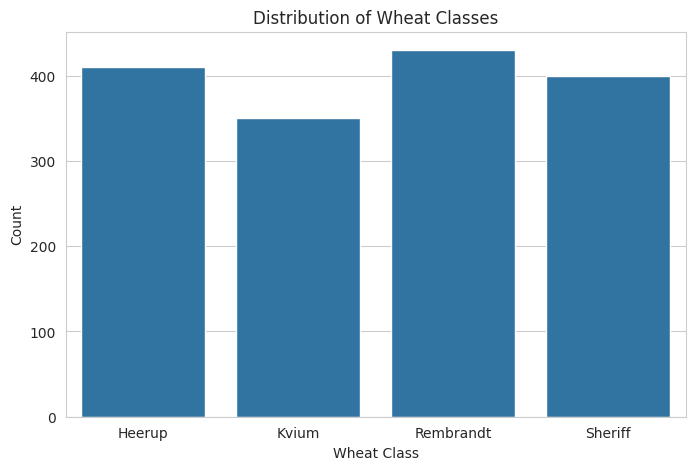

In [96]:


# For visualization purposes, let's create scaled DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=wavelength_columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=wavelength_columns)

# 3. Exploratory Data Analysis & Visualization (EDA)

# --- 3.1 Class Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(x=df_processed['Class'], order=class_names)
plt.title('Distribution of Wheat Classes')
plt.ylabel('Count')
plt.xlabel('Wheat Class')
plt.show()


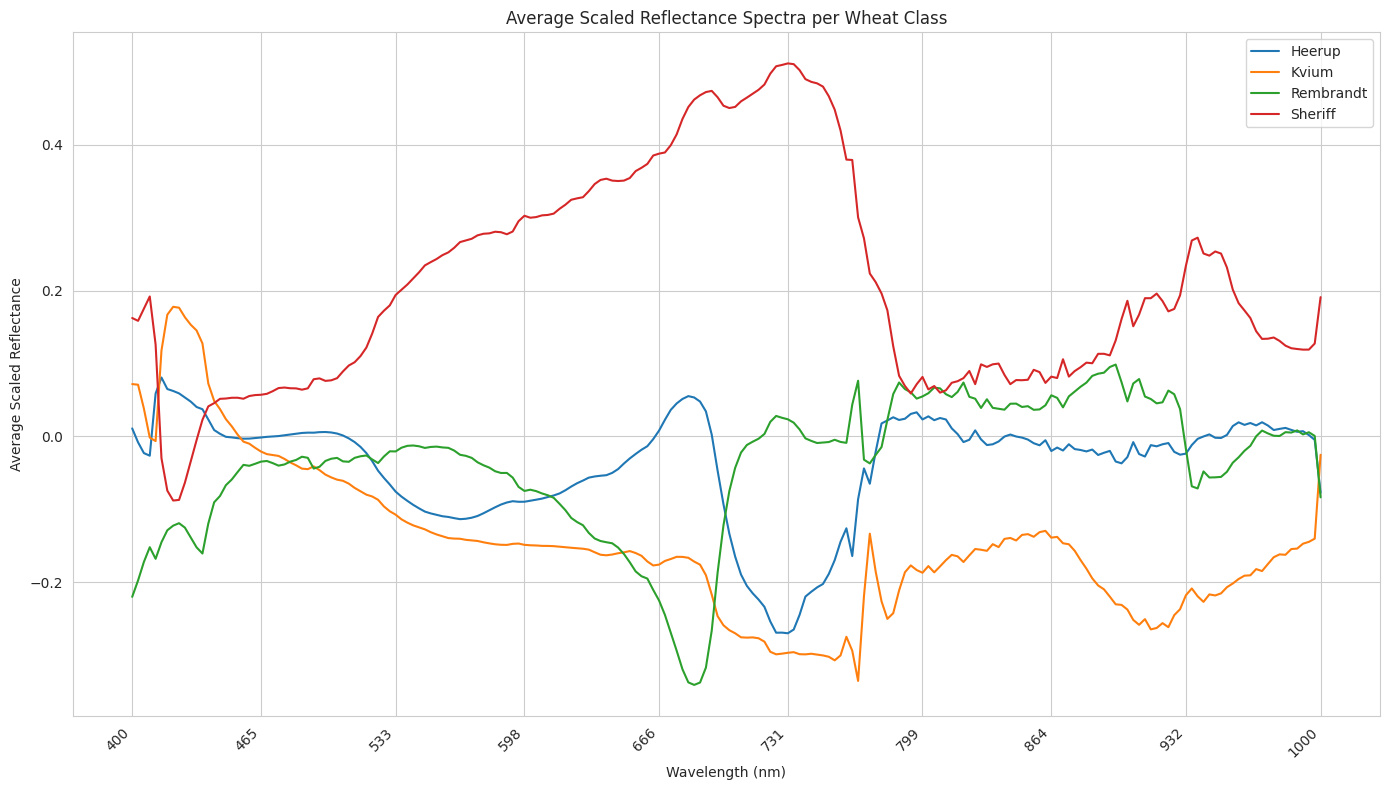

In [97]:
# --- 3.2 Average Reflectance Spectra per Wheat Class ---
# Combine scaled training data with target for easier plotting
df_train_viz = X_train_scaled_df.copy()
df_train_viz['Class'] = y_train.map(class_mapping).values # Use mapped names for legend


mean_spectra = df_train_viz.groupby('Class').mean()

# Convert wavelength column names to float for plotting
wavelengths = np.array(wavelength_columns, dtype=float)

plt.figure(figsize=(14, 8))
for wheat_class in class_names:
    plt.plot(wavelengths, mean_spectra.loc[wheat_class], label=wheat_class)

plt.title('Average Scaled Reflectance Spectra per Wheat Class')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Average Scaled Reflectance')
plt.legend()

# Show fewer x-ticks for readability
num_ticks = 10
tick_positions = np.linspace(0, len(wavelengths) - 1, num_ticks, dtype=int)
tick_labels = [str(int(wavelengths[i])) for i in tick_positions]
plt.xticks(ticks=wavelengths[tick_positions], labels=tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()



Selected key wavelengths for box plots: ['550.74', '668.97', '719.21', '799.01']


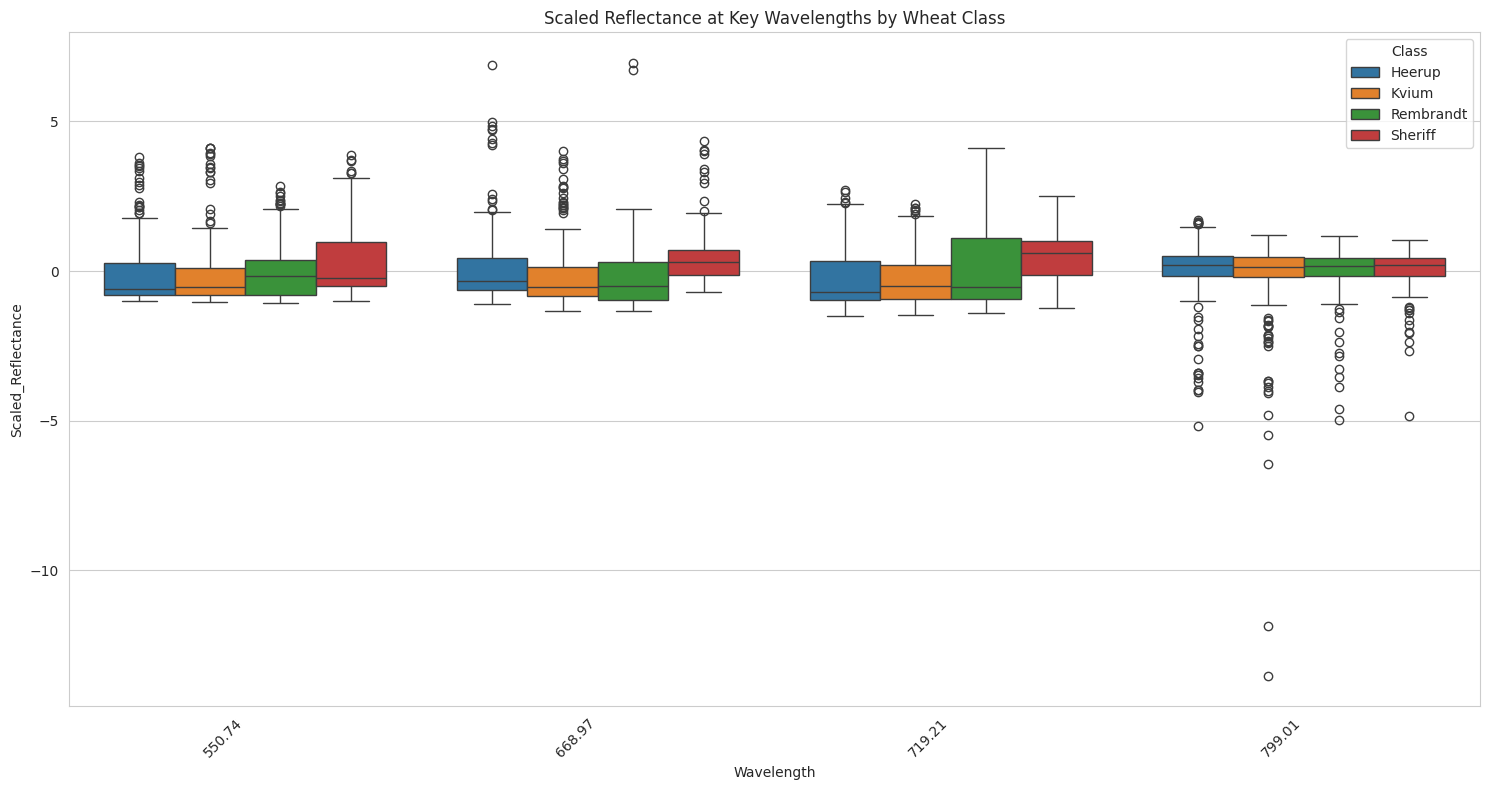

In [98]:
# --- 3.3 Box plots for specific key wavelengths ---
# Let's pick a few representative wavelengths
# Green (~550nm), Red (~670nm), Red-Edge (~720nm), NIR (~800nm)
key_wavelength_targets = [550, 670, 720, 800]
actual_key_wavelengths = [get_closest_wavelength(X.columns, wl) for wl in key_wavelength_targets]
print(f"\nSelected key wavelengths for box plots: {actual_key_wavelengths}")

# Prepare data for boxplot (melted format)
df_train_melted = pd.melt(df_train_viz, id_vars=['Class'], value_vars=actual_key_wavelengths,
                          var_name='Wavelength', value_name='Scaled_Reflectance')

plt.figure(figsize=(15, 8))
sns.boxplot(x='Wavelength', y='Scaled_Reflectance', hue='Class', data=df_train_melted, hue_order=class_names)
plt.title('Scaled Reflectance at Key Wavelengths by Wheat Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Explained variance by PCA components: [0.43549404 0.20602522]
Total explained variance by 2 components: 0.6415


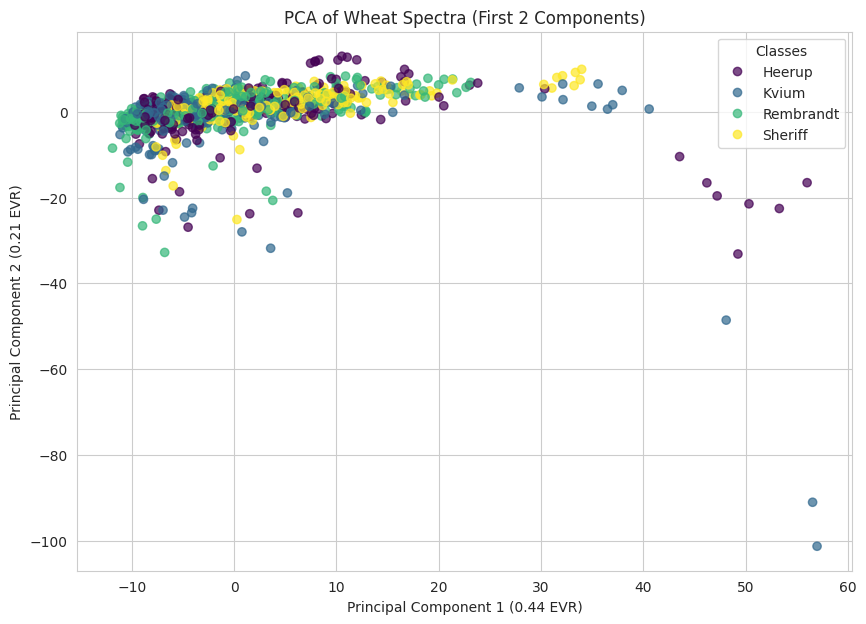

In [99]:

# --- 3.4 PCA Visualization ---
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f"\nExplained variance by PCA components: {pca.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.title('PCA of Wheat Spectra (First 2 Components)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2f} EVR)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2f} EVR)')
# Create a legend
handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title="Classes")
plt.show()

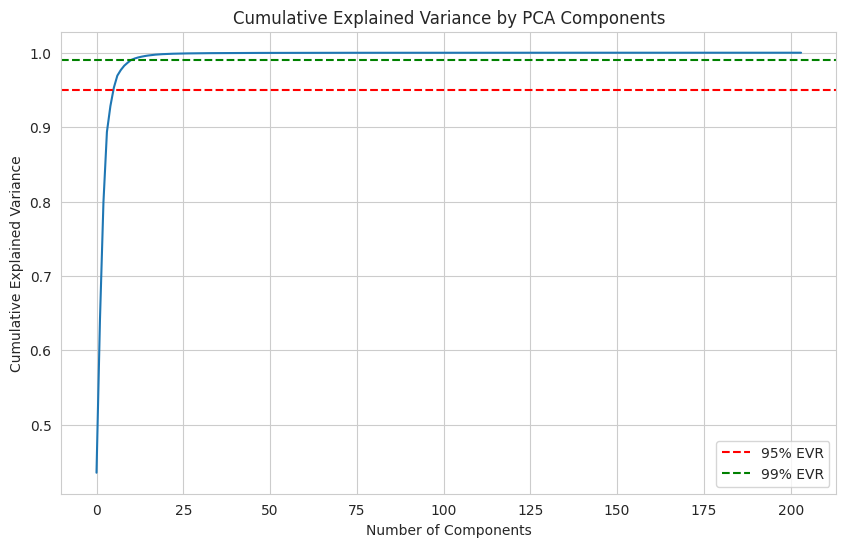

In [100]:
# Optional: PCA with more components to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% EVR')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% EVR')
plt.legend()
plt.show()

Number of components for 95% EVR: 6
Number of components for 99% EVR: 11


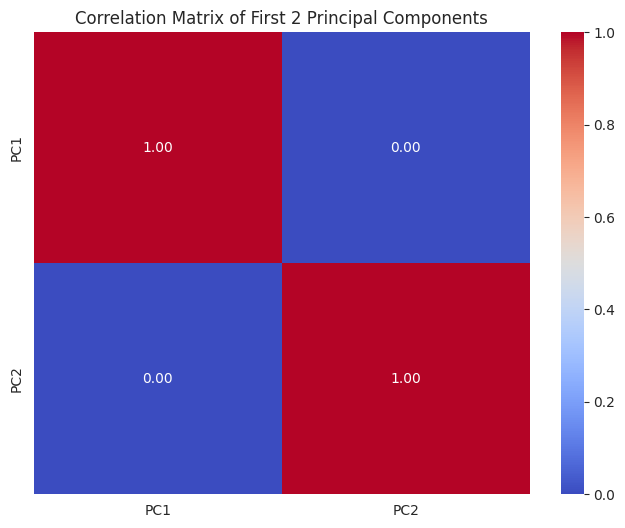

In [101]:
#@title pca for spectral data vs wheat class




# Number of components for 95% and 99% variance
n_comp_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
n_comp_99 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.99) + 1
print(f"Number of components for 95% EVR: {n_comp_95}")
print(f"Number of components for 99% EVR: {n_comp_99}")

# --- 3.5 Correlation Heatmap (on a few PCA components) ---
# A full heatmap of 200+ features would be unreadable.
# Let's do it on the first few PCA components.
n_pca_corr = min(10, X_train_pca.shape[1] if X_train_pca.shape[1] > 1 else n_comp_95) # Use up to 10 or available PCA components
if n_pca_corr > 1: # Only if we have more than 1 component
    pca_df_train = pd.DataFrame(X_train_pca[:, :n_pca_corr], columns=[f'PC{i+1}' for i in range(n_pca_corr)])
    correlation_matrix_pca = pca_df_train.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix_pca, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix of First {n_pca_corr} Principal Components')
    plt.show()
else:
    print("\nSkipping PCA correlation heatmap as only 1 or no PCA component was generated for this step.")


--- Model Training and Evaluation ---

Training Logistic Regression...
Accuracy for Logistic Regression: 0.7236
Classification Report for Logistic Regression:
               precision    recall  f1-score   support

      Heerup       0.64      0.68      0.66       103
       Kvium       0.77      0.59      0.67        87
   Rembrandt       0.69      0.78      0.73       108
     Sheriff       0.82      0.83      0.83       100

    accuracy                           0.72       398
   macro avg       0.73      0.72      0.72       398
weighted avg       0.73      0.72      0.72       398



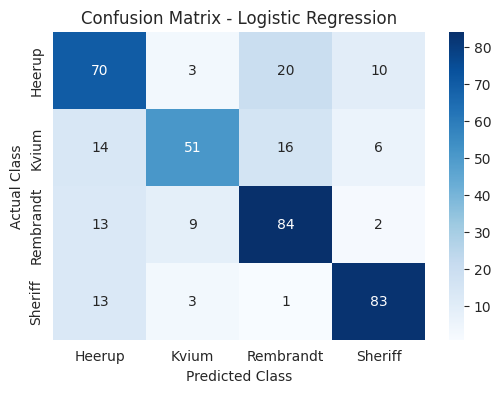


Training K-Nearest Neighbors...
Accuracy for K-Nearest Neighbors: 0.5226
Classification Report for K-Nearest Neighbors:
               precision    recall  f1-score   support

      Heerup       0.49      0.60      0.54       103
       Kvium       0.43      0.43      0.43        87
   Rembrandt       0.58      0.42      0.49       108
     Sheriff       0.60      0.64      0.62       100

    accuracy                           0.52       398
   macro avg       0.52      0.52      0.52       398
weighted avg       0.53      0.52      0.52       398



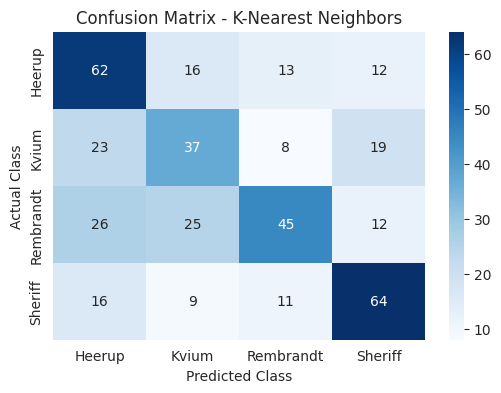


Training SVM (Linear Kernel)...
Accuracy for SVM (Linear Kernel): 0.7739
Classification Report for SVM (Linear Kernel):
               precision    recall  f1-score   support

      Heerup       0.65      0.75      0.70       103
       Kvium       0.82      0.67      0.73        87
   Rembrandt       0.78      0.81      0.80       108
     Sheriff       0.89      0.85      0.87       100

    accuracy                           0.77       398
   macro avg       0.78      0.77      0.77       398
weighted avg       0.78      0.77      0.77       398



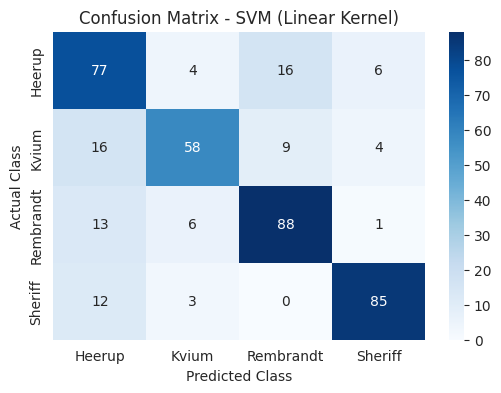


Training SVM (RBF Kernel)...
Accuracy for SVM (RBF Kernel): 0.5829
Classification Report for SVM (RBF Kernel):
               precision    recall  f1-score   support

      Heerup       0.50      0.61      0.55       103
       Kvium       0.47      0.25      0.33        87
   Rembrandt       0.68      0.70      0.69       108
     Sheriff       0.62      0.71      0.66       100

    accuracy                           0.58       398
   macro avg       0.57      0.57      0.56       398
weighted avg       0.57      0.58      0.57       398



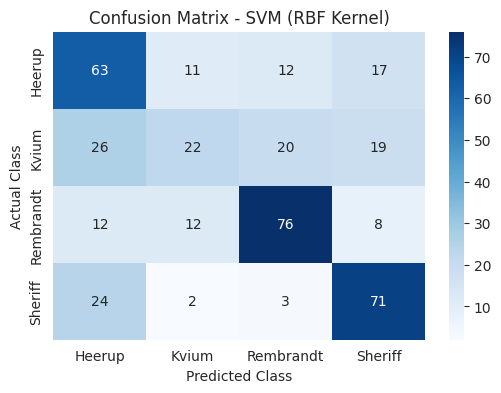


Training Random Forest...
Accuracy for Random Forest: 0.7136
Classification Report for Random Forest:
               precision    recall  f1-score   support

      Heerup       0.65      0.68      0.67       103
       Kvium       0.69      0.52      0.59        87
   Rembrandt       0.72      0.78      0.75       108
     Sheriff       0.77      0.85      0.81       100

    accuracy                           0.71       398
   macro avg       0.71      0.71      0.70       398
weighted avg       0.71      0.71      0.71       398



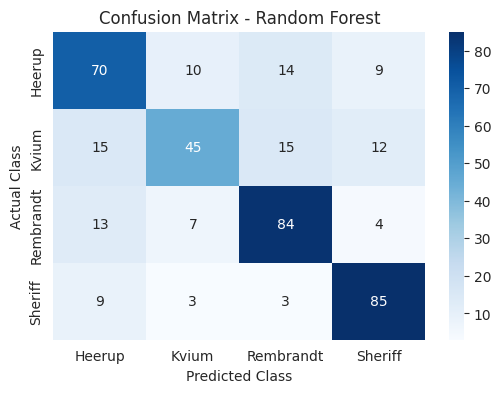


Training Gradient Boosting...
Accuracy for Gradient Boosting: 0.7035
Classification Report for Gradient Boosting:
               precision    recall  f1-score   support

      Heerup       0.66      0.66      0.66       103
       Kvium       0.61      0.47      0.53        87
   Rembrandt       0.75      0.79      0.77       108
     Sheriff       0.75      0.86      0.80       100

    accuracy                           0.70       398
   macro avg       0.69      0.69      0.69       398
weighted avg       0.70      0.70      0.70       398



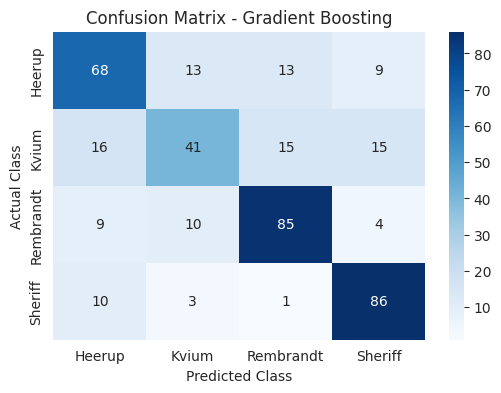


Training MLP Classifier...
Accuracy for MLP Classifier: 0.6809
Classification Report for MLP Classifier:
               precision    recall  f1-score   support

      Heerup       0.64      0.62      0.63       103
       Kvium       0.65      0.48      0.55        87
   Rembrandt       0.67      0.77      0.72       108
     Sheriff       0.75      0.82      0.78       100

    accuracy                           0.68       398
   macro avg       0.68      0.67      0.67       398
weighted avg       0.68      0.68      0.68       398



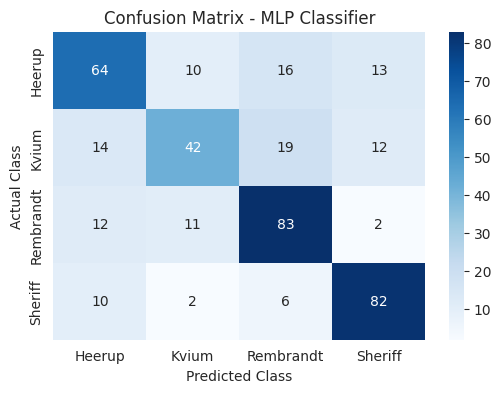

In [102]:
#@title multiple model train for spectral data to wheat class classification


# 4. Model Training & Evaluation

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'), # liblinear for multiclass
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5), # Default n_neighbors=5
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42), # Prob true for consistency if needed
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True)
}

results = {}

print("\n--- Model Training and Evaluation ---")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)

    results[name] = {
        "accuracy": accuracy,
        "precision_weighted": report['weighted avg']['precision'],
        "recall_weighted": report['weighted avg']['recall'],
        "f1_weighted": report['weighted avg']['f1-score'],
        "model_object": model # Store the trained model
    }

    print(f"Accuracy for {name}: {accuracy:.4f}")
    print(f"Classification Report for {name}:\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.show()

In [104]:
#@title find best model for  spectral data to wheat class classification
# 5. Model Comparison
results_df = pd.DataFrame(results).T.drop(columns=['model_object']) # Drop model object for display
results_df = results_df.sort_values(by='f1_weighted', ascending=False)

print("\n\n--- Model Comparison (Sorted by Weighted F1-score) ---")
print(results_df)

best_model_name = results_df.index[0]
best_model_obj = results[best_model_name]['model_object']
print(f"\nBest performing model based on weighted F1-score: {best_model_name}")



--- Model Comparison (Sorted by Weighted F1-score) ---
                     accuracy precision_weighted recall_weighted f1_weighted
SVM (Linear Kernel)  0.773869           0.781232        0.773869    0.774852
Logistic Regression  0.723618           0.728458        0.723618    0.722407
Random Forest        0.713568            0.71129        0.713568    0.708875
Gradient Boosting    0.703518           0.696492        0.703518    0.696988
MLP Classifier       0.680905           0.677525        0.680905      0.6753
SVM (RBF Kernel)     0.582915            0.57367        0.582915    0.569079
K-Nearest Neighbors  0.522613           0.528174        0.522613    0.519866

Best performing model based on weighted F1-score: SVM (Linear Kernel)


In [105]:
#@title save best model SVM for spectral data to wheat class classification
import joblib

# Save model, scaler, and label encoder together in a dictionary
bundle = {
    "model": best_model_obj,
    "scaler": scaler,
    "label_encoder": le
}

# Sanitize file name
import re
safe_model_name = re.sub(r'[^a-zA-Z0-9_\-]', '_', best_model_name)

joblib.dump(bundle, f"{safe_model_name}_bundle.pkl")
print(f"✅ Bundle saved as: {safe_model_name}_bundle.pkl")


✅ Bundle saved as: SVM__Linear_Kernel__bundle.pkl


In [107]:
#@title spectral data to wheat class classification svm interface
import joblib
import numpy as np
import pandas as pd

def predict_and_report(bundle_path, reflectance_data, true_labels=None):
    """
    Load model bundle, predict on reflectance data, and print results nicely.

    Args:
        bundle_path (str): Path to saved model+scaler+encoder bundle.
        reflectance_data (pd.DataFrame or np.ndarray): Input feature rows.
        true_labels (list or np.ndarray, optional): True class labels (strings).
    """
    bundle = joblib.load(bundle_path)
    model = bundle["model"]
    scaler = bundle["scaler"]
    le = bundle["label_encoder"]

    # Ensure 2D array
    if isinstance(reflectance_data, pd.Series):
        reflectance_data = reflectance_data.to_frame().T
    elif isinstance(reflectance_data, np.ndarray) and reflectance_data.ndim == 1:
        reflectance_data = reflectance_data.reshape(1, -1)

    # Scale features
    reflectance_scaled = scaler.transform(reflectance_data)

    # Predict encoded labels and decode to class names
    pred_encoded = model.predict(reflectance_scaled)
    pred_labels = le.inverse_transform(pred_encoded)

    # Print nicely
    print("\n--- Prediction Results ---")
    for i, pred_class in enumerate(pred_labels):
        print(f"Sample {i+1}: Predicted Class = {pred_class}")
        if true_labels is not None:
            print(f"          True Class      = {true_labels[i]}")
            correct = (pred_class == true_labels[i])
            print(f"          Correct?        = {'Yes' if correct else 'No'}")
        print("-" * 30)

    # If true labels provided, print overall accuracy
    if true_labels is not None:
        true_encoded = le.transform(true_labels)
        accuracy = np.mean(pred_encoded == true_encoded)
        print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")

    return pred_labels  # return predicted classes if needed
# Load bundle and test on fresh data sample
bundle_path = "SVM__Linear_Kernel__bundle.pkl"

# Suppose you freshly load your test data and labels again:
data_url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv"
df = pd.read_csv(data_url)

# Same preprocessing as before
df_processed = df.drop('ImageId', axis=1)
X = df_processed.drop(['Class'], axis=1)
y = df_processed['Class']

# Now pick some samples fresh, for example 5 rows
sample_data = X.iloc[:5]
true_labels = y.iloc[:5].values  # raw string labels

# Call prediction function
predict_and_report(bundle_path, sample_data, true_labels)



--- Prediction Results ---
Sample 1: Predicted Class = Sheriff
          True Class      = Kvium
          Correct?        = No
------------------------------
Sample 2: Predicted Class = Sheriff
          True Class      = Sheriff
          Correct?        = Yes
------------------------------
Sample 3: Predicted Class = Rembrandt
          True Class      = Rembrandt
          Correct?        = Yes
------------------------------
Sample 4: Predicted Class = Sheriff
          True Class      = Sheriff
          Correct?        = Yes
------------------------------
Sample 5: Predicted Class = Sheriff
          True Class      = Sheriff
          Correct?        = Yes
------------------------------

Overall Accuracy: 80.00%


array(['Sheriff', 'Sheriff', 'Rembrandt', 'Sheriff', 'Sheriff'],
      dtype=object)

Epoch 1/50, Loss: 1.3749, Accuracy: 38.21%
Epoch 2/50, Loss: 1.1164, Accuracy: 51.34%
Epoch 3/50, Loss: 1.0153, Accuracy: 55.03%
Epoch 4/50, Loss: 0.9174, Accuracy: 61.32%
Epoch 5/50, Loss: 0.8340, Accuracy: 65.41%
Epoch 6/50, Loss: 0.7919, Accuracy: 67.69%
Epoch 7/50, Loss: 0.7164, Accuracy: 71.38%
Epoch 8/50, Loss: 0.6955, Accuracy: 73.11%
Epoch 9/50, Loss: 0.6635, Accuracy: 73.19%
Epoch 10/50, Loss: 0.6431, Accuracy: 74.84%
Epoch 11/50, Loss: 0.6245, Accuracy: 75.16%
Epoch 12/50, Loss: 0.5771, Accuracy: 77.52%
Epoch 13/50, Loss: 0.5318, Accuracy: 78.93%
Epoch 14/50, Loss: 0.5064, Accuracy: 80.27%
Epoch 15/50, Loss: 0.4727, Accuracy: 81.37%
Epoch 16/50, Loss: 0.4581, Accuracy: 81.29%
Epoch 17/50, Loss: 0.4726, Accuracy: 82.08%
Epoch 18/50, Loss: 0.4486, Accuracy: 82.15%
Epoch 19/50, Loss: 0.4170, Accuracy: 84.36%
Epoch 20/50, Loss: 0.3982, Accuracy: 84.04%
Epoch 21/50, Loss: 0.3803, Accuracy: 84.91%
Epoch 22/50, Loss: 0.3440, Accuracy: 87.81%
Epoch 23/50, Loss: 0.3547, Accuracy: 86.6

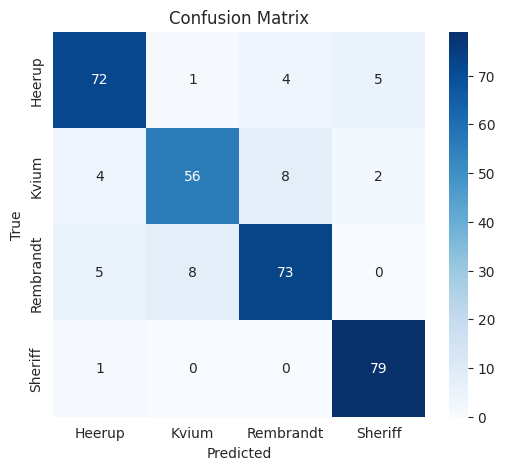

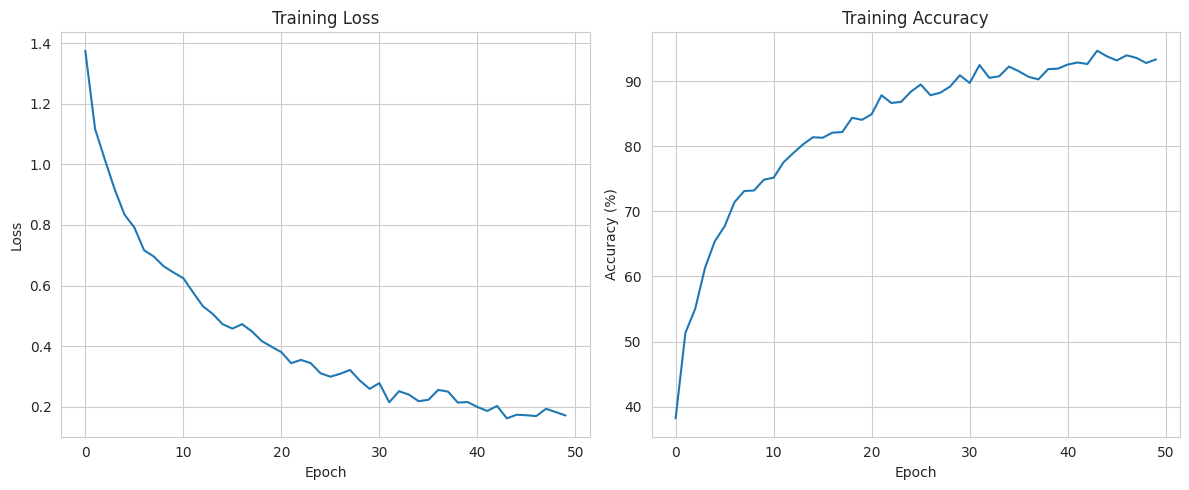

Sample Prediction
True class: Heerup
Predicted class: Heerup

Image ID     : 875
True Class   : Sheriff
Predicted    : Sheriff
Match        : ✅ Correct

Image ID     : 1091
True Class   : Sheriff
Predicted    : Sheriff
Match        : ✅ Correct

Image ID     : 1341
True Class   : Rembrandt
Predicted    : Rembrandt
Match        : ✅ Correct

Image ID     : 649
True Class   : Sheriff
Predicted    : Sheriff
Match        : ✅ Correct

Image ID     : 114
True Class   : Sheriff
Predicted    : Sheriff
Match        : ✅ Correct


In [90]:
#@title predict wheat class from spectral data using cnn1D tensorflow
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv"
df = pd.read_csv(url)

# Drop ImageId and extract features/labels
df = df.drop(columns=["ImageId"])
X = df.drop(columns=["Class"]).values
y = df["Class"].values

# Encode class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # shape: (N, 1, D)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 1D CNN model
class CNN1D(nn.Module):
    def __init__(self, num_classes):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * (X_train_tensor.shape[2] // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

# Initialize model
model = CNN1D(num_classes=len(class_names))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
torch.save(model.state_dict(), "tensorflow_spectral.pth")
print("Model saved as tensorflow_spectral.pth")

# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Plot confusion matrix
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Sample prediction test
sample_idx = 0
sample = X_test_tensor[sample_idx].unsqueeze(0)
true_class = y_test[sample_idx]

model.eval()
with torch.no_grad():
    output = model(sample)
    predicted_class_idx = torch.argmax(output, dim=1).item()
    predicted_class = class_names[predicted_class_idx]

print(f"Sample Prediction")
print(f"True class: {class_names[true_class]}")
print(f"Predicted class: {predicted_class}")



import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

# CNN1D model class
class CNN1D(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * (input_length // 4), 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)

# Load dataset
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/dataset.csv"
df = pd.read_csv(url)

# Recreate scaler and encoder
X = df.drop(columns=["ImageId", "Class"]).values
y = df["Class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

input_length = X_scaled.shape[1]
num_classes = len(label_encoder.classes_)

# Load model
model = CNN1D(input_length=input_length, num_classes=num_classes)
model.load_state_dict(torch.load("tensorflow_spectral.pth", map_location=torch.device("cpu")))
model.eval()

# Predict and verify function
import random

def predict_sample_random():
    index = random.randint(0, len(df) - 1)
    row = df.iloc[index]
    image_id = row["ImageId"]
    true_label = row["Class"]

    features = row.drop(["ImageId", "Class"]).values.reshape(1, -1)
    features_scaled = scaler.transform(features)
    input_tensor = torch.tensor(features_scaled, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        predicted_label = label_encoder.inverse_transform([pred_idx])[0]

    print(f"\nImage ID     : {image_id}")
    print(f"True Class   : {true_label}")
    print(f"Predicted    : {predicted_label}")
    print(f"Match        : {'✅ Correct' if true_label == predicted_label else '❌ Wrong'}")
for _ in range(5):
  predict_sample_random()

# Wheat Leaf Classification using hyperspectral tiff iamge

Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]



Epoch 1/30
Train Loss: 1.3958, Acc: 0.3514
Validation Acc: 0.4497
✅ Model saved!

Epoch 2/30
Train Loss: 1.1277, Acc: 0.4953
Validation Acc: 0.6352
✅ Model saved!

Epoch 3/30
Train Loss: 0.9823, Acc: 0.5881
Validation Acc: 0.5503

Epoch 4/30
Train Loss: 0.9691, Acc: 0.5802
Validation Acc: 0.5849

Epoch 5/30
Train Loss: 0.8797, Acc: 0.6258
Validation Acc: 0.6164

Epoch 6/30
Train Loss: 0.8827, Acc: 0.6321
Validation Acc: 0.6635
✅ Model saved!

Epoch 7/30
Train Loss: 0.8238, Acc: 0.6604
Validation Acc: 0.6855
✅ Model saved!

Epoch 8/30
Train Loss: 0.7699, Acc: 0.6926
Validation Acc: 0.6101

Epoch 9/30
Train Loss: 0.7583, Acc: 0.6989
Validation Acc: 0.6572

Epoch 10/30
Train Loss: 0.7624, Acc: 0.6871
Validation Acc: 0.6918
✅ Model saved!

Epoch 11/30
Train Loss: 0.7386, Acc: 0.7020
Validation Acc: 0.6761

Epoch 12/30
Train Loss: 0.7153, Acc: 0.7131
Validation Acc: 0.6761

Epoch 13/30
Train Loss: 0.6813, Acc: 0.7264
Validation Acc: 0.6855

Epoch 14/30
Train Loss: 0.6742, Acc: 0.7272
Valid

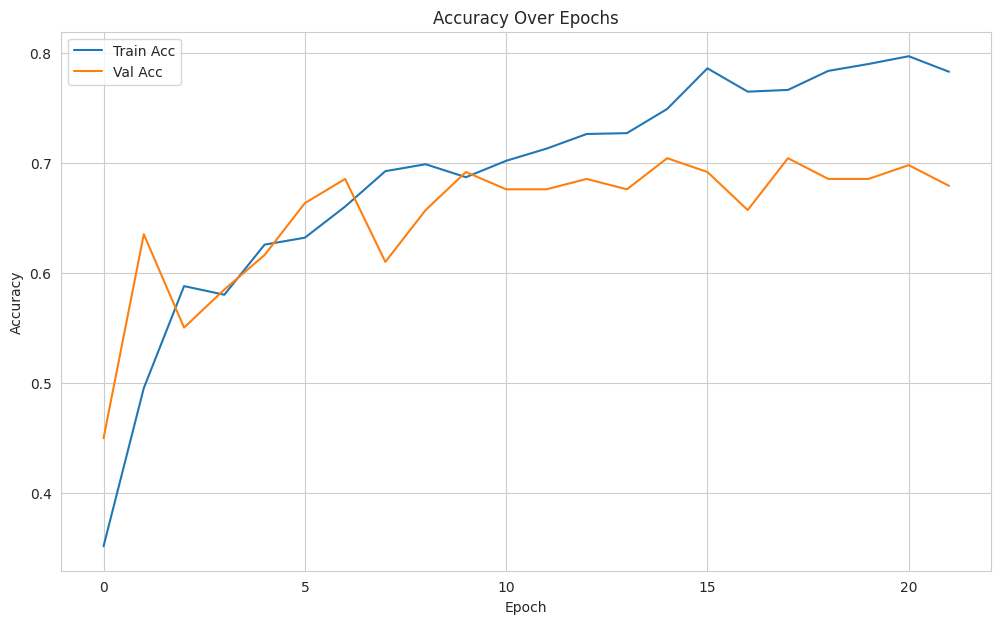

              precision    recall  f1-score   support

      Heerup       0.69      0.72      0.70        82
       Kvium       0.79      0.70      0.74        70
   Rembrandt       0.69      0.70      0.69        86
     Sheriff       0.67      0.70      0.69        80

    accuracy                           0.70       318
   macro avg       0.71      0.70      0.71       318
weighted avg       0.71      0.70      0.70       318



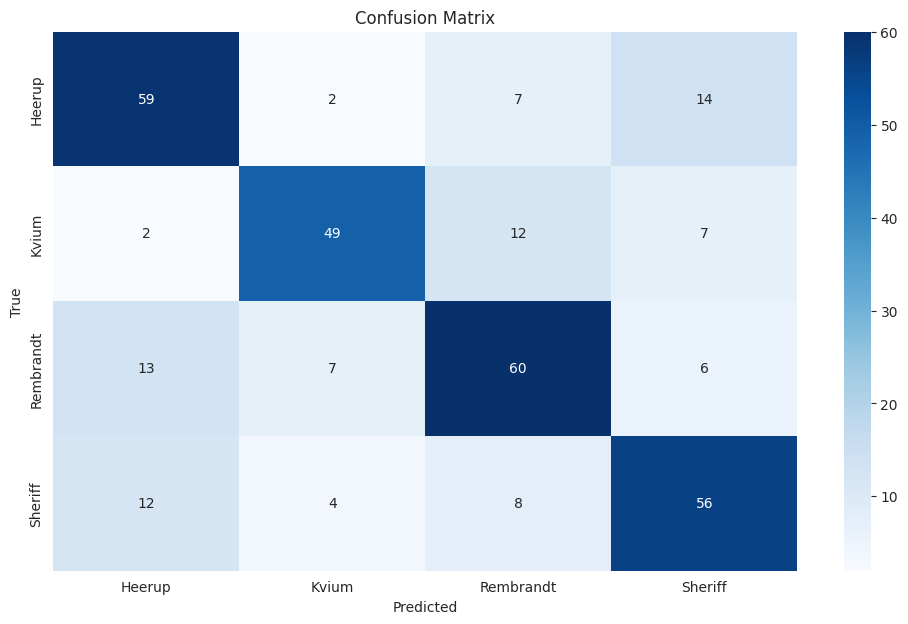

In [72]:
#@title  Hyperspectral Wheat Leaf Classification using 2D ResNet50 (Full Image, Extended Training, Early Stopping)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ⚙️ Settings
CULTIVARS = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']
NUM_CLASSES = len(CULTIVARS)
SELECTED_BANDS = [88, 51, 24]
DATA_DIR = "/content/hyperleaf2024"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 📊 Load and preprocess CSV
df = pd.read_csv(CSV_PATH)
df["ImageId"] = df["ImageId"].astype(int).astype(str).str.zfill(5)

# 🧠 Custom Dataset
class HyperLeafDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, bands=SELECTED_BANDS):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.bands = bands

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['ImageId']}.tiff")
        cube = tifffile.imread(img_path)
        rgb = cube[self.bands, :, :].astype(np.float32)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        label = row[CULTIVARS].values.argmax()

        if self.transform:
            rgb = self.transform(rgb)

        return rgb, label

# 🧪 Transforms (Preserve original size)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 352)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🧪 Split and Load Data
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df[CULTIVARS].values.argmax(axis=1))
train_ds = HyperLeafDataset(train_df, IMAGE_DIR, transform=transform)
val_ds = HyperLeafDataset(val_df, IMAGE_DIR, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# 🧠 ResNet50 Classifier
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(DEVICE)

# 🔧 Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

# 🚀 Training Loop with Early Stopping
EPOCHS = 30
best_acc = 0
patience = 7
trigger_times = 0
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_loss, correct = 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    train_acc = correct / len(train_ds)
    train_accuracies.append(train_acc)
    print(f"Train Loss: {total_loss / len(train_loader):.4f}, Acc: {train_acc:.4f}")

    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    val_acc = correct / len(val_ds)
    val_accuracies.append(val_acc)
    print(f"Validation Acc: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "resnet50_best_model.pth")
        print("✅ Model saved!")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}")
            break

# 📊 Accuracy Plot
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# 📊 Final Evaluation
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        all_preds += out.argmax(1).cpu().tolist()
        all_labels += y.cpu().tolist()

print(classification_report(all_labels, all_preds, target_names=CULTIVARS))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CULTIVARS, yticklabels=CULTIVARS)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [77]:
#@title resnet50 model accuracy
def evaluate_model_accuracy(model_path="resnet50_best_model.pth", dataset=val_ds, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size)

    # Load model
    model = models.resnet50(pretrained=False)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES)
    )
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    accuracy = correct / total
    print(f"✅ Model Accuracy: {accuracy * 100:.2f}%")
    return accuracy
evaluate_model_accuracy()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model Accuracy: 70.44%


0.7044025157232704

In [78]:
#@title resnet50 model accuracy on training data
evaluate_model_accuracy(dataset=train_ds)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model Accuracy: 83.96%


0.839622641509434

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Actual: Heerup
🔮 Predicted: Heerup


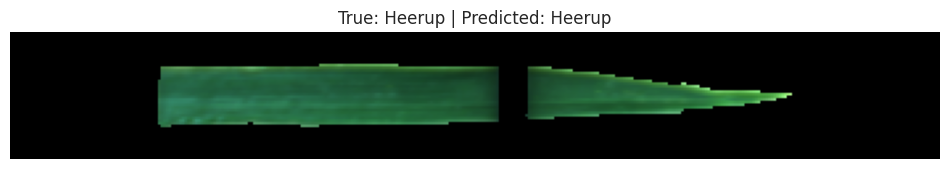

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Actual: Heerup
🔮 Predicted: Heerup


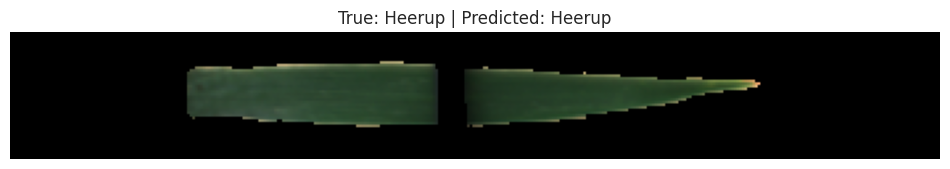

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Actual: Sheriff
🔮 Predicted: Sheriff


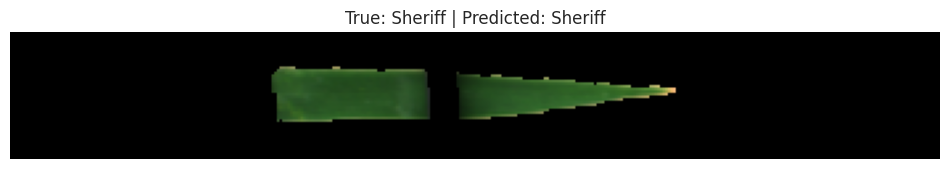

In [81]:
#@title resnet50 wheat class classification interface
import random

def verify_sample_prediction(model_path="resnet50_best_model.pth", dataset=val_ds, class_names=CULTIVARS):
    # Load model
    model = models.resnet50(pretrained=False)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES)
    )
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    # Pick a random sample
    idx = random.randint(0, len(dataset) - 1)
    image, true_label = dataset[idx]
    input_tensor = image.unsqueeze(0).to(DEVICE)

    # Predict
    with torch.no_grad():
        output = model(input_tensor)
        pred_label = output.argmax(1).item()

    # Show result
    print(f"✅ Actual: {class_names[true_label]}")
    print(f"🔮 Predicted: {class_names[pred_label]}")

    # Optional: show the image
    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Denormalize
    img_np = np.clip(img_np, 0, 1)
    plt.imshow(img_np)
    plt.title(f"True: {class_names[true_label]} | Predicted: {class_names[pred_label]}")
    plt.axis('off')
    plt.show()
for _ in range(3):
    verify_sample_prediction()


Using device: cuda


Downloading: "https://download.pytorch.org/models/convnext_large-ea097f82.pth" to /root/.cache/torch/hub/checkpoints/convnext_large-ea097f82.pth
100%|██████████| 755M/755M [00:05<00:00, 158MB/s]



Epoch 1/10
Train Loss: 1.4006, Acc: 0.2469
Validation Acc: 0.2704
✅ Model saved!

Epoch 2/10
Train Loss: 1.3956, Acc: 0.2390
Validation Acc: 0.2704

Epoch 3/10
Train Loss: 1.3872, Acc: 0.2767
Validation Acc: 0.3365
✅ Model saved!

Epoch 4/10
Train Loss: 1.2981, Acc: 0.3553
Validation Acc: 0.4277
✅ Model saved!

Epoch 5/10
Train Loss: 1.1301, Acc: 0.4976
Validation Acc: 0.4717
✅ Model saved!

Epoch 6/10
Train Loss: 0.8931, Acc: 0.6368
Validation Acc: 0.7044
✅ Model saved!

Epoch 7/10
Train Loss: 0.6883, Acc: 0.7327
Validation Acc: 0.7296
✅ Model saved!

Epoch 8/10
Train Loss: 0.5599, Acc: 0.7987
Validation Acc: 0.7013

Epoch 9/10
Train Loss: 0.4828, Acc: 0.8231
Validation Acc: 0.8270
✅ Model saved!

Epoch 10/10
Train Loss: 0.3904, Acc: 0.8569
Validation Acc: 0.8899
✅ Model saved!


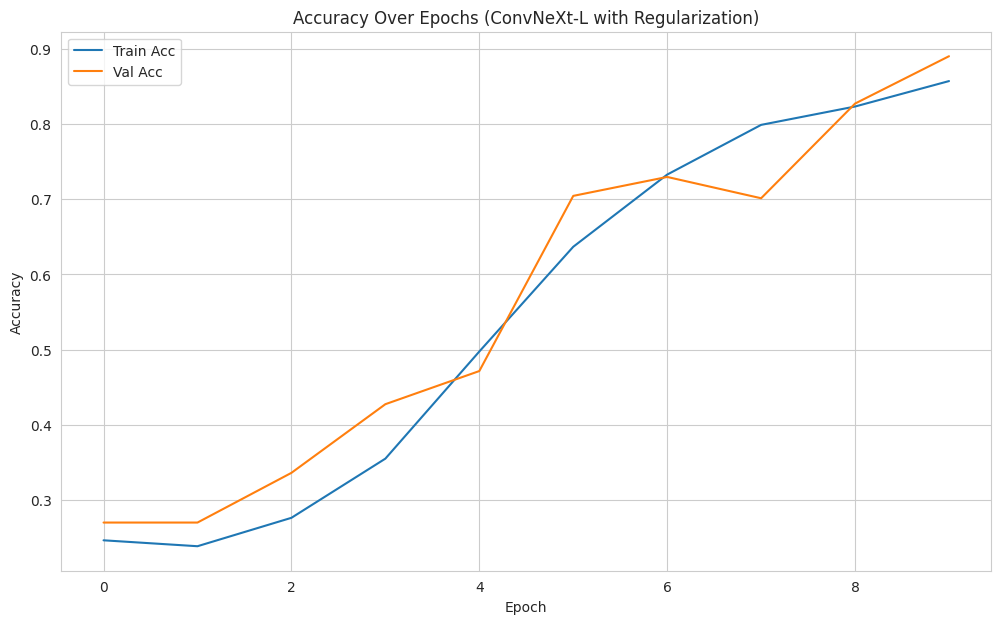

              precision    recall  f1-score   support

      Heerup       0.92      0.85      0.89        82
       Kvium       0.95      0.81      0.88        70
   Rembrandt       0.83      0.95      0.89        86
     Sheriff       0.89      0.93      0.91        80

    accuracy                           0.89       318
   macro avg       0.90      0.89      0.89       318
weighted avg       0.89      0.89      0.89       318



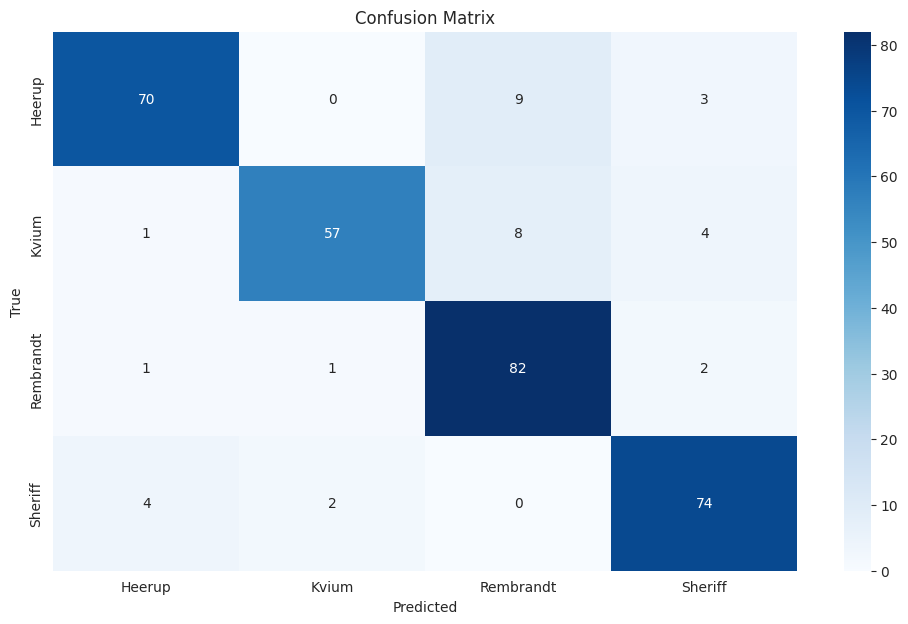

In [108]:
#@title Hyperspectral Wheat Leaf Classification using ConvNeXt-L with Better Regularization

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_large, ConvNeXt_Large_Weights

# ⚙️ Settings
CULTIVARS = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']
NUM_CLASSES = len(CULTIVARS)
SELECTED_BANDS = [88, 51, 24]
DATA_DIR = "/content/hyperleaf2024"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 📊 Load and preprocess CSV
df = pd.read_csv(CSV_PATH)
df["ImageId"] = df["ImageId"].astype(int).astype(str).str.zfill(5)

# 🧠 Custom Dataset
class HyperLeafDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, bands=SELECTED_BANDS):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.bands = bands

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['ImageId']}.tiff")
        cube = tifffile.imread(img_path)
        rgb = cube[self.bands, :, :].astype(np.float32)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        label = row[CULTIVARS].values.argmax()

        if self.transform:
            rgb = self.transform(rgb)

        return rgb, label

# 🧪 Data Augmentation
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🧪 Split and Load Data
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df[CULTIVARS].values.argmax(axis=1))
train_ds = HyperLeafDataset(train_df, IMAGE_DIR, transform=transform_train)
val_ds = HyperLeafDataset(val_df, IMAGE_DIR, transform=transform_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# 🧠 ConvNeXt-Large Classifier
weights = ConvNeXt_Large_Weights.DEFAULT
model = convnext_large(weights=weights)
model.classifier[2] = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
)
model = model.to(DEVICE)

# 🔧 Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)

# 🚀 Training Loop with Early Stopping
EPOCHS = 10
best_acc = 0
patience = 5
trigger_times = 0
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_loss, correct = 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
    train_acc = correct / len(train_ds)
    train_accuracies.append(train_acc)
    print(f"Train Loss: {total_loss / len(train_loader):.4f}, Acc: {train_acc:.4f}")

    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    val_acc = correct / len(val_ds)
    val_accuracies.append(val_acc)
    print(f"Validation Acc: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_convnext_model.pth")
        print("✅ Model saved!")
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}")
            break

# 📊 Accuracy Plot
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.legend()
plt.title("Accuracy Over Epochs (ConvNeXt-L with Regularization)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# 📊 Final Evaluation
model.load_state_dict(torch.load("best_convnext_model.pth"))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        all_preds += out.argmax(1).cpu().tolist()
        all_labels += y.cpu().tolist()

print(classification_report(all_labels, all_preds, target_names=CULTIVARS))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CULTIVARS, yticklabels=CULTIVARS)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [121]:
#@title ConvNeXt-L interface
import os
import torch
import numpy as np
import pandas as pd
import tifffile
import random
from torchvision import transforms
from torchvision.models import convnext_large, ConvNeXt_Large_Weights
import torch.nn as nn

# Constants (adjust paths if needed)
DATA_DIR = "/content/hyperleaf2024"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_CSV_PATH = os.path.join(DATA_DIR, "test.csv")
CULTIVARS = ['Heerup', 'Kvium', 'Rembrandt', 'Sheriff']
SELECTED_BANDS = [88, 51, 24]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(CULTIVARS)

# Model building helper (same as training)
def build_model():
    weights = ConvNeXt_Large_Weights.DEFAULT
    model = convnext_large(weights=weights)
    model.classifier[2] = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
    )
    model.to(DEVICE)
    return model

# Image preprocessing (same as validation transform)
def preprocess_image(img):
    transform_val = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    return transform_val(img)

def predict_random_samples(image_filenames, model_path="best_convnext_model.pth"):
    """
    Load model and predict classes for given list of TIFF image filenames.
    Prints prediction and correctness compared to true labels in CSV.

    Args:
        image_filenames (list[str]): List of TIFF image filenames (e.g. ['00001.tiff', ...])
    """
    if not image_filenames:
        print("No image filenames provided.")
        return

    # Load CSV once to get true labels
    df = pd.read_csv(CSV_PATH)
    df["ImageId"] = df["ImageId"].astype(int).astype(str).str.zfill(5)

    # Build and load model
    model = build_model()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    correct_preds = 0
    total_preds = 0

    for filename in image_filenames:
        image_id = filename.split(".")[0]
        row = df[df["ImageId"] == image_id]
        if row.empty:
            print(f"Image {filename} not found in train.csv. Skipping...")
            continue

        img_path = os.path.join(IMAGE_DIR, filename)
        if not os.path.exists(img_path):
            print(f"Image file {img_path} not found. Skipping...")
            continue

        cube = tifffile.imread(img_path)

        rgb = cube[SELECTED_BANDS, :, :].astype(np.float32)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        x = preprocess_image(rgb).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            out = model(x)
            pred_idx = out.argmax(1).item()

        pred_class = CULTIVARS[pred_idx]
        true_class_idx = row[CULTIVARS].values.argmax()
        true_class = CULTIVARS[true_class_idx]

        is_correct = pred_class == true_class

        print(f"Image: {filename}")
        print(f"  Predicted: {pred_class}")
        print(f"  True     : {true_class}")
        print(f"  Correct? : {'Yes' if is_correct else 'No'}\n")

        total_preds += 1
        if is_correct:
            correct_preds += 1

    print(f"Total Correct Predictions: {correct_preds} / {total_preds}")

predict_random_samples(['00090.tiff','00014.tiff'])

Image: 00090.tiff
  Predicted: Sheriff
  True     : Sheriff
  Correct? : Yes

Image: 00014.tiff
  Predicted: Kvium
  True     : Kvium
  Correct? : Yes

Total Correct Predictions: 2 / 2


#  multiclass regression where we use tiff images as input need to predict GrainWeight, Gsw, PhiPS2, Fertilizer

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 32.8MB/s]


Epoch 1/30 - Train Loss: 0.0599, Val Loss: 0.0672 | MAE: 465.93, R²: -0.7868
✅ Model saved!
Epoch 2/30 - Train Loss: 0.0275, Val Loss: 0.0612 | MAE: 470.15, R²: -0.7100
✅ Model saved!
Epoch 3/30 - Train Loss: 0.0224, Val Loss: 0.0547 | MAE: 409.28, R²: -0.5061
✅ Model saved!
Epoch 4/30 - Train Loss: 0.0189, Val Loss: 0.0505 | MAE: 390.24, R²: -0.3398
✅ Model saved!
Epoch 5/30 - Train Loss: 0.0167, Val Loss: 0.0444 | MAE: 351.04, R²: -0.1974
✅ Model saved!
Epoch 6/30 - Train Loss: 0.0140, Val Loss: 0.0422 | MAE: 330.57, R²: -0.0855
✅ Model saved!
Epoch 7/30 - Train Loss: 0.0132, Val Loss: 0.0362 | MAE: 296.06, R²: -0.0735
✅ Model saved!
Epoch 8/30 - Train Loss: 0.0123, Val Loss: 0.0336 | MAE: 284.63, R²: -0.0535
✅ Model saved!
Epoch 9/30 - Train Loss: 0.0107, Val Loss: 0.0333 | MAE: 309.19, R²: 0.0740
✅ Model saved!
Epoch 10/30 - Train Loss: 0.0105, Val Loss: 0.0319 | MAE: 295.68, R²: 0.0065
✅ Model saved!
Epoch 11/30 - Train Loss: 0.0094, Val Loss: 0.0384 | MAE: 350.27, R²: 0.0315
Epoc

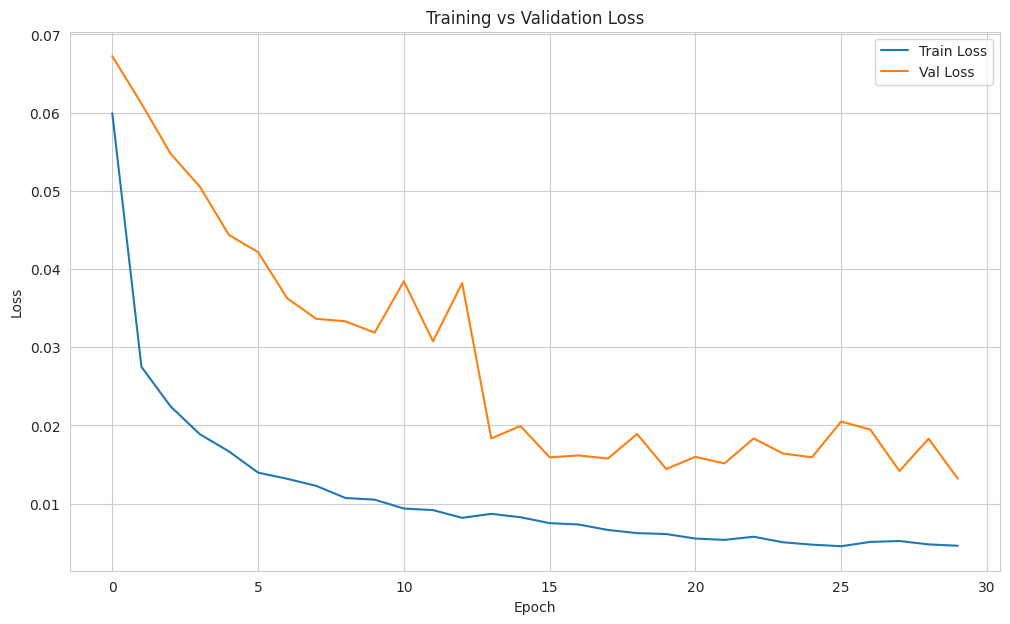


📊 Final Regression Metrics:
GrainWeight: MAE = 781.71, R² = 0.7463
Gsw: MAE = 0.02, R² = 0.1567
PhiPS2: MAE = 0.07, R² = 0.3101
Fertilizer: MAE = 0.13, R² = 0.8552


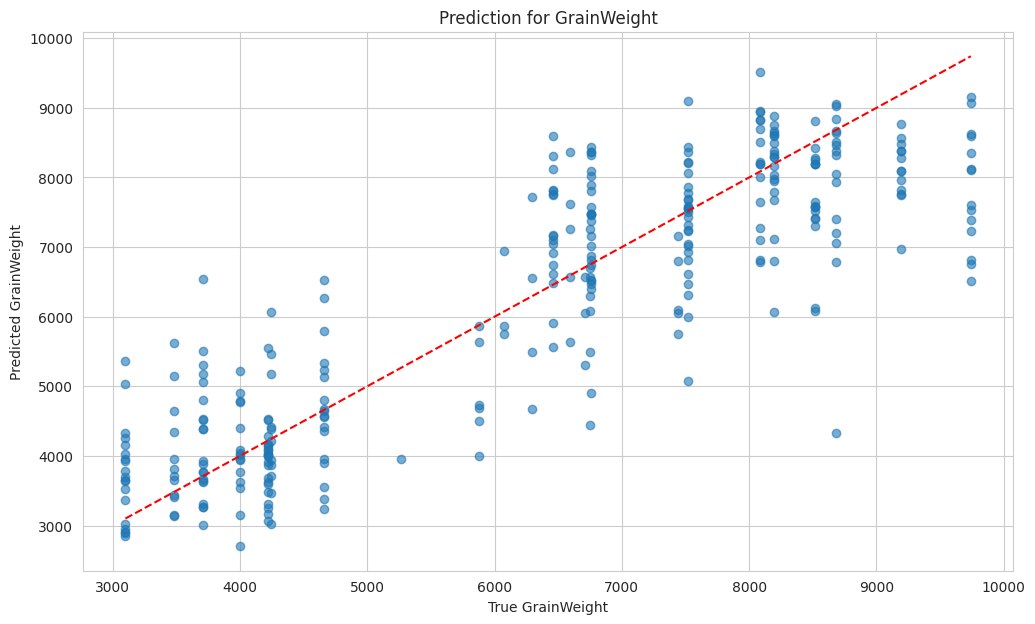

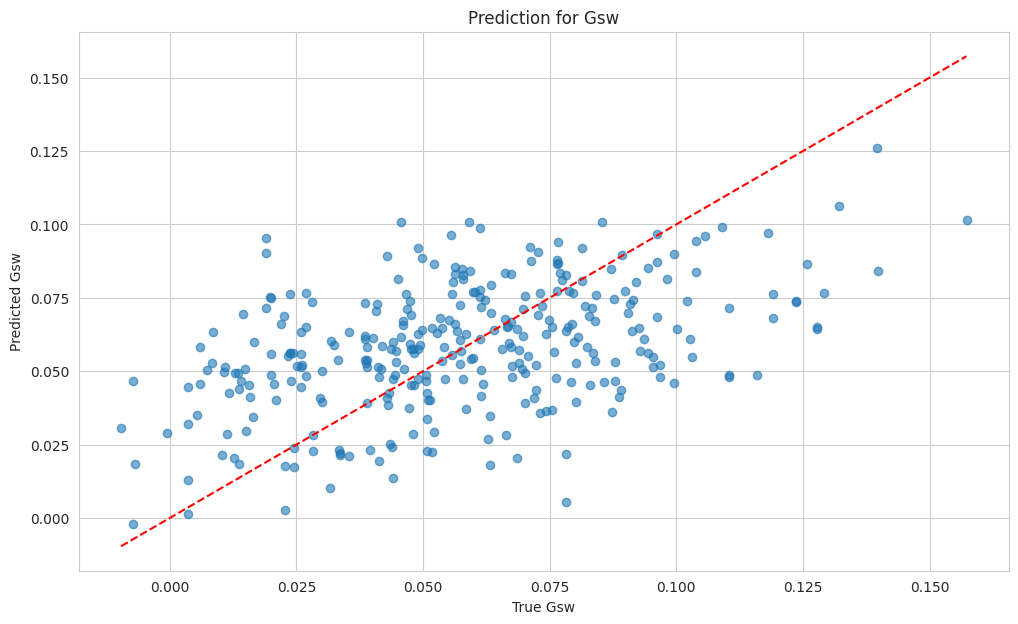

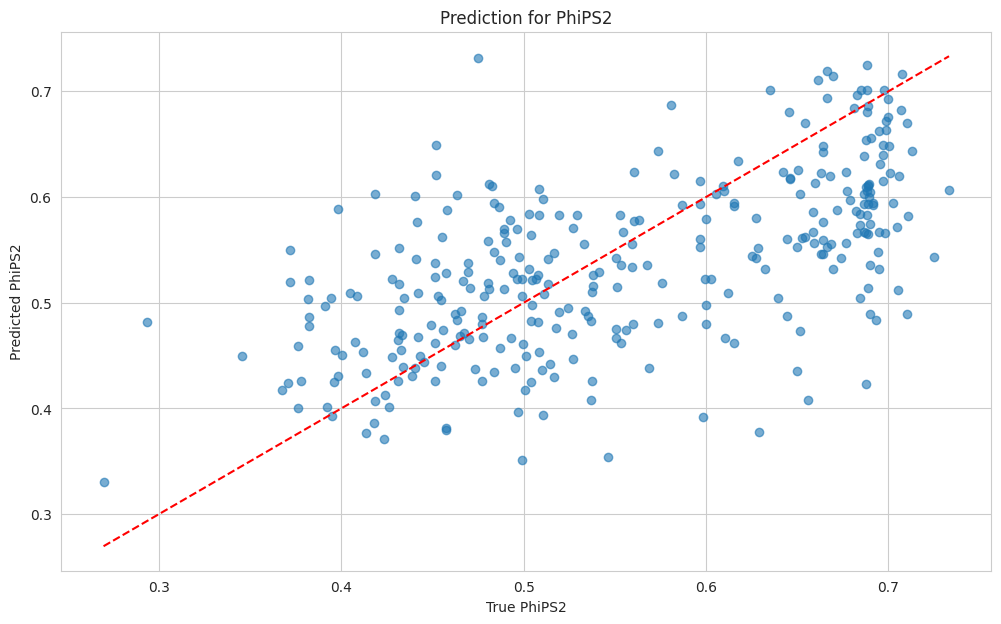

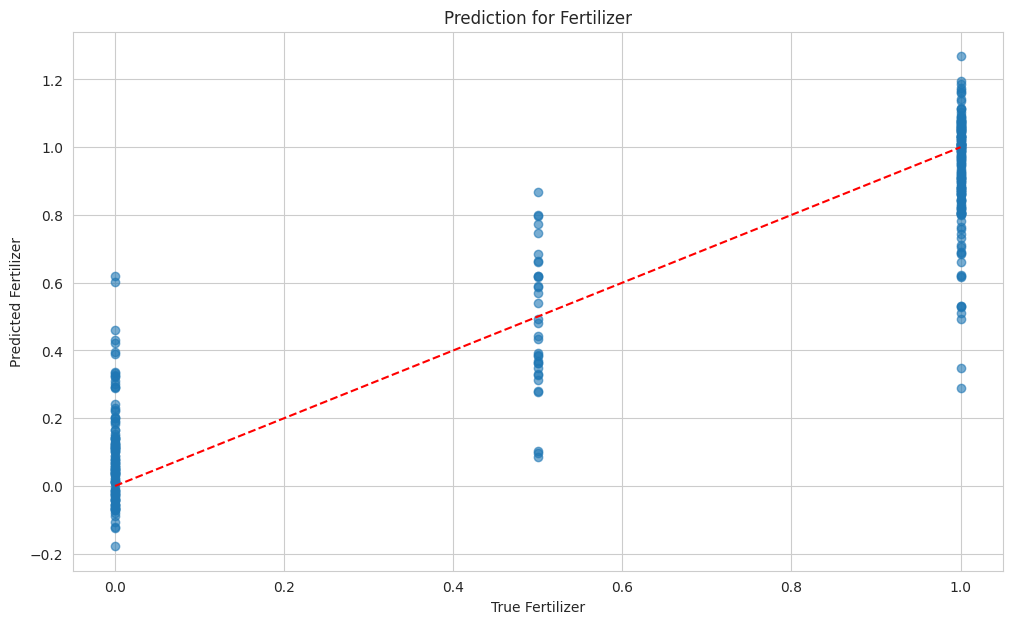

In [122]:
#@title MobileNetV3-Small for Hyperspectral Regression on Wheat Traits

"""
MobileNetV3-Small for Hyperspectral Regression on Wheat Traits
"""

import os
import numpy as np
import pandas as pd
import tifffile
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ⚙️ Settings
DATA_DIR = "/content/hyperleaf2024"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
CSV_PATH = os.path.join(DATA_DIR, "train.csv")
BATCH_SIZE = 32
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGETS = ['GrainWeight', 'Gsw', 'PhiPS2', 'Fertilizer']
SELECTED_BANDS = [88, 51, 24]

# 📊 Load CSV
df = pd.read_csv(CSV_PATH)
df["ImageId"] = df["ImageId"].astype(int).astype(str).str.zfill(5)

# ✅ Normalize Targets
scaler = MinMaxScaler()
df[TARGETS] = scaler.fit_transform(df[TARGETS])

# 🧠 Dataset
class HyperspectralRegressionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, bands=SELECTED_BANDS):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.bands = bands

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['ImageId']}.tiff")
        cube = tifffile.imread(img_path)
        rgb = cube[self.bands, :, :].astype(np.float32)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        if self.transform:
            rgb = self.transform(rgb)

        label = torch.tensor(row[TARGETS].values.astype(np.float32))
        return rgb, label

# 🧪 Transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🔀 Split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = HyperspectralRegressionDataset(train_df, IMAGE_DIR, transform=transform)
val_ds = HyperspectralRegressionDataset(val_df, IMAGE_DIR, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# 🧠 Model
model = models.mobilenet_v3_small(pretrained=True)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(TARGETS))
model = model.to(DEVICE)

# 🔧 Loss & Optimizer
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 🚀 Training Loop
train_losses, val_losses = [], []
best_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    preds, targets = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE)
            output = model(x).cpu().numpy()
            preds.append(output)
            targets.append(y.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    val_loss = criterion(torch.tensor(preds), torch.tensor(targets)).item()
    val_losses.append(val_loss)

    mae = mean_absolute_error(scaler.inverse_transform(targets), scaler.inverse_transform(preds))
    r2 = r2_score(scaler.inverse_transform(targets), scaler.inverse_transform(preds))

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | MAE: {mae:.2f}, R²: {r2:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_mobilenetv3_regression.pth")
        print("✅ Model saved!")

# 📊 Plot Loss Curve
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# 📈 Final Evaluation
model.load_state_dict(torch.load("best_mobilenetv3_regression.pth"))
model.eval()
preds, targets = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        output = model(x).cpu().numpy()
        preds.append(output)
        targets.append(y.numpy())

preds = np.concatenate(preds)
targets = np.concatenate(targets)

preds = scaler.inverse_transform(preds)
targets = scaler.inverse_transform(targets)

print("\n📊 Final Regression Metrics:")
for i, name in enumerate(TARGETS):
    mae = mean_absolute_error(targets[:, i], preds[:, i])
    r2 = r2_score(targets[:, i], preds[:, i])
    print(f"{name}: MAE = {mae:.2f}, R² = {r2:.4f}")

# 🔍 Scatter plots
for i, name in enumerate(TARGETS):
    plt.scatter(targets[:, i], preds[:, i], alpha=0.6)
    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"Prediction for {name}")
    plt.grid(True)
    plt.plot([targets[:, i].min(), targets[:, i].max()],
             [targets[:, i].min(), targets[:, i].max()], 'r--')
    plt.show()


In [130]:
#@title MobileNetV3-Small Hyperspectral Regression avg result
r2_scores = [
    r2_score(targets[:, i], preds[:, i])
    for i in range(len(TARGETS))
]
average_r2 = np.mean(r2_scores)
print(f"🔢 Average R² Score: {average_r2:.4f}")
mae_scores = [
    mean_absolute_error(targets[:, i], preds[:, i])
    for i in range(len(TARGETS))
]
average_mae = np.mean(mae_scores)
print(f"📏 Average MAE: {average_mae:.4f}")


🔢 Average R² Score: 0.5171
📏 Average MAE: 195.4819


In [133]:
#@title interface for MobileNetV3-Small Hyperspectral Regression
def evaluate_random_samples(model_path, csv_path, image_dir, n=10, bands=SELECTED_BANDS):
    import random

    # Load data
    df = pd.read_csv(csv_path)
    df["ImageId"] = df["ImageId"].astype(int).astype(str).str.zfill(5)

    # Normalize targets using same scaler as training
    target_data = df[TARGETS].values
    scaler = MinMaxScaler()
    scaler.fit(target_data)
    df[TARGETS] = scaler.transform(target_data)

    # Sample N rows
    sampled_df = df.sample(n=n, random_state=42).reset_index(drop=True)

    # Load model
    model = models.mobilenet_v3_small(pretrained=False)
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(TARGETS))
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    preds, trues = [], []

    for i, row in sampled_df.iterrows():
        img_id = row["ImageId"]
        img_path = os.path.join(image_dir, f"{img_id}.tiff")

        cube = tifffile.imread(img_path)
        rgb = cube[bands, :, :].astype(np.float32)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        x = transform(rgb).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            y_pred = model(x).cpu().numpy()[0]

        preds.append(y_pred)
        trues.append(row[TARGETS].values)

    preds = np.array(preds)
    trues = np.array(trues)

    # De-normalize
    preds = scaler.inverse_transform(preds)
    trues = scaler.inverse_transform(trues)

    print(f"\n🔍 Inference on {n} Random Samples")
    for i in range(n):
        print(f"\n🌿Image ID: {sampled_df.iloc[i]['ImageId']}")
        for j, target in enumerate(TARGETS):
            print(f"  {target:10s} → Pred: {preds[i, j]:.2f} | True: {trues[i, j]:.2f}")

    print("\n📊 Evaluation Metrics:")
    for j, target in enumerate(TARGETS):
        mae = mean_absolute_error(trues[:, j], preds[:, j])
        r2 = r2_score(trues[:, j], preds[:, j])
        print(f"  {target:10s} → MAE: {mae:.2f}, R²: {r2:.4f}")
evaluate_random_samples(
    model_path="best_mobilenetv3_regression.pth",
    csv_path="/content/hyperleaf2024/train.csv",
    image_dir="/content/hyperleaf2024/images",
    n=10  # or any number you want
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



🔍 Inference on 10 Random Samples

🌿Image ID: 01667
  GrainWeight → Pred: 3387.16 | True: 4660.00
  Gsw        → Pred: 0.06 | True: 0.07
  PhiPS2     → Pred: 0.40 | True: 0.39
  Fertilizer → Pred: 0.01 | True: 0.00

🌿Image ID: 00629
  GrainWeight → Pred: 7224.54 | True: 9742.00
  Gsw        → Pred: 0.06 | True: 0.13
  PhiPS2     → Pred: 0.52 | True: 0.50
  Fertilizer → Pred: 0.82 | True: 1.00

🌿Image ID: 02263
  GrainWeight → Pred: 7265.84 | True: 6753.00
  Gsw        → Pred: 0.08 | True: 0.06
  PhiPS2     → Pred: 0.59 | True: 0.66
  Fertilizer → Pred: 0.68 | True: 0.50

🌿Image ID: 00372
  GrainWeight → Pred: 8367.24 | True: 6760.00
  Gsw        → Pred: 0.07 | True: 0.02
  PhiPS2     → Pred: 0.50 | True: 0.60
  Fertilizer → Pred: 1.19 | True: 1.00

🌿Image ID: 00954
  GrainWeight → Pred: 7201.66 | True: 8680.00
  Gsw        → Pred: 0.08 | True: 0.12
  PhiPS2     → Pred: 0.51 | True: 0.54
  Fertilizer → Pred: 0.77 | True: 1.00

🌿Image ID: 00152
  GrainWeight → Pred: 7158.24 | True: 7438.

#  multiclass regression where we use spectral data as input need to predict GrainWeight, Gsw, PhiPS2, Fertilizer

Retained 204 wavelength features.
Removed 0 strictly binary (0/1 only) columns.

--- Linear Regression ---
GrainWeight: MSE = 1059351.5363, R2 = 0.7475
Gsw: MSE = 0.0007, R2 = 0.2275
PhiPS2: MSE = 0.0029, R2 = 0.7421
Fertilizer: MSE = 0.0299, R2 = 0.8629

--- Random Forest ---
GrainWeight: MSE = 598583.8315, R2 = 0.8573
Gsw: MSE = 0.0006, R2 = 0.3079
PhiPS2: MSE = 0.0045, R2 = 0.6032
Fertilizer: MSE = 0.0172, R2 = 0.9211

--- XGBoost ---
GrainWeight: MSE = 578845.0625, R2 = 0.8620
Gsw: MSE = 0.0007, R2 = 0.2757
PhiPS2: MSE = 0.0039, R2 = 0.6543
Fertilizer: MSE = 0.0207, R2 = 0.9049
Epoch 1/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 11315929.0000 - mae: 1597.7952 - val_loss: 10769034.0000 - val_mae: 1552.2778
Epoch 2/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11345942.0000 - mae: 1598.3307 - val_loss: 10610538.0000 - val_mae: 1540.3462
Epoch 3/300
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10895559.0000 - mae: 1564.8333 - val_loss: 10343028.0000 - val_mae: 1519.8270

<ipython-input-158-014224ee557a>:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scores_df, x='Avg R² Score', y='Model', palette='viridis')


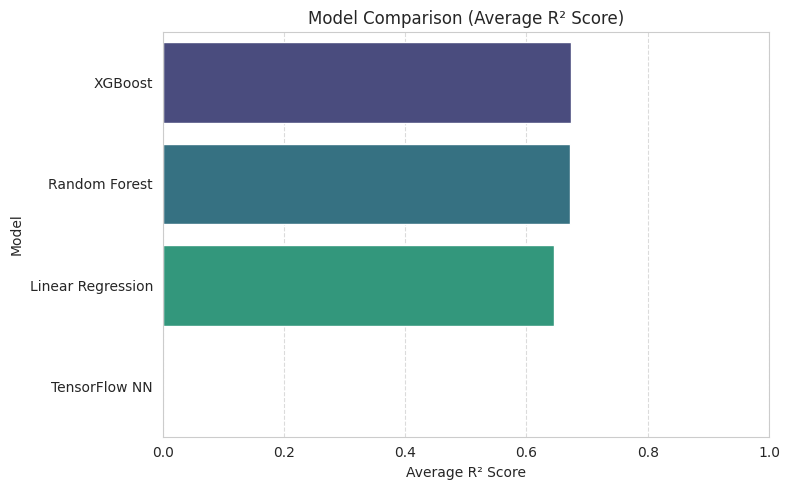

In [158]:
#@title spectral data to multi class regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/regression_dataset.csv"
df = pd.read_csv(url)

# Define target columns and columns to exclude from features
target_cols = ['GrainWeight', 'Gsw', 'PhiPS2', 'Fertilizer']
non_feature_cols = ['ImageId', 'Class', 'Heerup', 'Kvium', 'Rembrandt', 'Sheriff'] + target_cols

# Prepare features (X) and targets (y)
X = df.drop(columns=non_feature_cols)
y = df[target_cols]

# Function to check if a column contains only 0s and 1s
def is_strictly_binary(col):
    unique_vals = col.dropna().unique()
    return set(unique_vals).issubset({0, 1})

# Identify strictly binary columns (only 0s and 1s)
binary_cols = [col for col in X.columns if is_strictly_binary(X[col])]

# Drop strictly binary columns
X_filtered = X.drop(columns=binary_cols)
print(f"Retained {X_filtered.shape[1]} wavelength features.")
print(f"Removed {len(binary_cols)} strictly binary (0/1 only) columns.")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Scale features for TensorFlow neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Evaluation function to print metrics per target and return average R2
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    r2 = r2_score(y_test, y_pred, multioutput='raw_values')
    print(f"\n--- {name} ---")
    for i, col in enumerate(y_test.columns):
        print(f"{col}: MSE = {mse[i]:.4f}, R2 = {r2[i]:.4f}")
    return np.mean(r2)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
r2_lr = evaluate_model(lr, X_test, y_test, "Linear Regression")

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
r2_rf = evaluate_model(rf, X_test, y_test, "Random Forest")

# XGBoost Regressor
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
r2_xgb = evaluate_model(xgb, X_test, y_test, "XGBoost")

# TensorFlow Neural Network model
model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(4)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=300, batch_size=16, callbacks=[early_stop], verbose=1)

# Predict and evaluate TensorFlow model
y_pred_nn = model.predict(X_test_scaled)
r2_nn = r2_score(y_test, y_pred_nn, multioutput='raw_values')

print("\n--- TensorFlow Neural Network ---")
for i, col in enumerate(y_test.columns):
    print(f"{col}: R2 = {r2_nn[i]:.4f}")

# Collect average R2 scores
model_scores = {
    "Linear Regression": r2_lr,
    "Random Forest": r2_rf,
    "XGBoost": r2_xgb,
    "TensorFlow NN": np.mean(r2_nn)
}

# Plot model comparison
scores_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Avg R² Score'])
scores_df = scores_df.sort_values(by='Avg R² Score', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=scores_df, x='Avg R² Score', y='Model', palette='viridis')
plt.title('Model Comparison (Average R² Score)')
plt.xlabel('Average R² Score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [160]:
#@title best model save
import pickle

models_dict = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    # Add TensorFlow model if you want, but saving TF models via pickle is NOT recommended
}

best_model_name = max(model_scores, key=model_scores.get)
best_model_score = model_scores[best_model_name]

print(f"\n🏆 Best Model: {best_model_name} with Avg R² Score = {best_model_score:.4f}")

if best_model_name in models_dict:
    best_model = models_dict[best_model_name]
    model_path = "best_model.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(best_model, f)
    print(f"Saved best model '{best_model_name}' to {model_path}")
else:
    print(f"Best model '{best_model_name}' is not in models_dict or is TensorFlow NN — save separately if needed.")



🏆 Best Model: XGBoost with Avg R² Score = 0.6742
Saved best model 'XGBoost' to best_model.pkl


In [161]:
#@title XGBoost  interface
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
import pickle

# Load data
url = "https://raw.githubusercontent.com/p-p-p-p/precision-agriculture/refs/heads/main/dataset/regression_dataset.csv"
df = pd.read_csv(url)

# Define targets and non-feature columns
target_cols = ['GrainWeight', 'Gsw', 'PhiPS2', 'Fertilizer']
non_feature_cols = ['ImageId', 'Class', 'Heerup', 'Kvium', 'Rembrandt', 'Sheriff'] + target_cols

# Identify wavelength columns (numeric column names not in non-feature)
wavelength_cols = [col for col in df.columns if col not in non_feature_cols and col.replace('.', '', 1).isdigit()]

# Drop wavelength columns that contain ONLY 0 or 1 values
cols_to_drop = []
for col in wavelength_cols:
    unique_vals = df[col].unique()
    if set(unique_vals).issubset({0, 1}):
        cols_to_drop.append(col)

print(f"Dropping {len(cols_to_drop)} wavelength columns with only 0 or 1 values.")

# Prepare features and targets
X = df.drop(columns=non_feature_cols + cols_to_drop)
y = df[target_cols]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train multi-output XGB regressor
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save model using pickle
model_path = "best_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

# Prepare test dataframe for evaluation
test_data = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Define load and test function
def load_and_test_xgb_pkl(model_path, test_df, target_cols, n_samples=5):
    import pickle

    with open(model_path, "rb") as f:
        loaded_model = pickle.load(f)

    sample_df = test_df.sample(n=n_samples, random_state=42)
    X_sample = sample_df.drop(columns=target_cols)
    y_true = sample_df[target_cols]

    y_pred = loaded_model.predict(X_sample)

    print(f"\nTesting {n_samples} random samples:")
    for i in range(n_samples):
        print(f"\nSample index: {sample_df.index[i]}")
        print("Actual:", y_true.iloc[i].to_dict())
        print("Predicted:", {col: round(y_pred[i][j], 4) for j, col in enumerate(target_cols)})

# Run test on saved model
load_and_test_xgb_pkl(model_path, test_data, target_cols, n_samples=5)


Dropping 0 wavelength columns with only 0 or 1 values.
Model saved to best_model.pkl

Testing 5 random samples:

Sample index: 73
Actual: {'GrainWeight': 6460.0, 'Gsw': 0.012654, 'PhiPS2': 0.596441, 'Fertilizer': 1.0}
Predicted: {'GrainWeight': np.float32(6576.9155), 'Gsw': np.float32(0.0413), 'PhiPS2': np.float32(0.5261), 'Fertilizer': np.float32(1.0019)}

Sample index: 277
Actual: {'GrainWeight': 6760.0, 'Gsw': 0.043404, 'PhiPS2': 0.480611, 'Fertilizer': 1.0}
Predicted: {'GrainWeight': np.float32(7008.6006), 'Gsw': np.float32(0.0531), 'PhiPS2': np.float32(0.471), 'Fertilizer': np.float32(0.9977)}

Sample index: 25
Actual: {'GrainWeight': 3713.0, 'Gsw': 0.072612, 'PhiPS2': 0.466943, 'Fertilizer': 0.0}
Predicted: {'GrainWeight': np.float32(4115.043), 'Gsw': np.float32(0.059), 'PhiPS2': np.float32(0.4573), 'Fertilizer': np.float32(-0.0079)}

Sample index: 256
Actual: {'GrainWeight': 9196.0, 'Gsw': 0.099453, 'PhiPS2': 0.418443, 'Fertilizer': 1.0}
Predicted: {'GrainWeight': np.float32(838